# **NYC TLC Trip Record Data Report: Comprehensive Profiling & Analysis (2020)**

## Summary

This notebook provides a comprehensive exploratory data analysis and cleaning pipeline for NYC Taxi and Limousine Commission (TLC) yellow taxi trip records from 2020. The analysis is structured in three phases:

1. **Data Discovery & Profiling**: Understanding raw data structure, schema validation, and completeness metrics
2. **Data Quality Assessment**: Identifying anomalies, inconsistencies, duplicates, and invalid records
3. **Data Cleaning & Feature Engineering**: Removing invalid records, standardizing formats, and creating derived features
4. **Analysis & Insights**: Temporal, spatial, and behavioral pattern discovery on cleaned data

---

## Introduction & Problem Context

### Problem Statement

New York City taxi activity produces a massive volume of trip records, making it a valuable source for studying urban mobility, travel demand, and transportation patterns. The 2020 TLC dataset encompasses:

- **Multi-million trip records** across five boroughs
- **Complex fare structures** with multiple components (base, extra, tax, tip, tolls, surcharge)
- **Temporal variations** from hourly demand swings to seasonal patterns
- **Data quality challenges** typical of large-scale transportation datasets

Key challenges addressed in this analysis:

1. **Missing & NULL values**: Identifying complete missingness (e.g., airport_fee) vs. sparse nulls
2. **Data type inconsistencies**: Ensuring numeric fields are properly typed for analysis
3. **Temporal anomalies**: Detecting impossible timestamps (dropoff before pickup)
4. **Distance & duration outliers**: Identifying implausible trip metrics
5. **Passenger count violations**: Records outside realistic taxi capacity (0 or >8)
6. **Fare amount problems**: Negative fares and fare aggregation inconsistencies
7. **Duplicate records**: Finding and removing exact and near-duplicate trips

### Objectives

This project aims to:

- **Profile**: Understand data completeness, distributions, and schema
- **Clean**: Remove invalid, duplicate, and inconsistent records
- **Prepare**: Engineer features for analysis and modeling
- **Analyze**: Discover temporal demand patterns, spatial hotspots, and trip behavior
- **Discover Insights**: Extract actionable patterns for transportation planning

## Project Scope and Analysis Questions

### Focus of the Study

This project uses NYC TLC trip record data to study taxi mobility patterns in New York City, with the analysis restricted to 2020 because the full dataset is too large to process comfortably in this project. Working with one year still provides enough volume to analyze demand, spatial concentration, and trip behavior at city scale.

### Main Questions

- How did trip volume change across the year, across months, and across weekdays?
- Which pickup and dropoff locations were most active?
- How do trip distance, duration, and fare vary across different time periods?
- Are there patterns in passenger counts, payment types, or vendor behavior?
- What data cleaning steps are necessary before the data can be used reliably for analysis or modeling?

### Expected Outputs

- Cleaned and standardized trip records for the 2020 subset
- Temporal summaries by hour, day, week, and month
- Spatial summaries of pickup and dropoff activity
- Feature-engineered variables for downstream analytics
- A short set of findings to support transportation and mobility analysis

## Related Work

### Urban Mobility Analytics

Taxi trip data has been widely used to study movement patterns in cities, identify high-demand corridors, and understand how transportation demand changes over time. Previous work often combines temporal aggregation with spatial analysis to reveal mobility hotspots and travel regularities.

### Demand Forecasting and Trip Modeling

- **Time Series Analysis**: Historical trip counts are commonly modeled to forecast hourly, daily, or monthly demand
- **Spatial-Temporal Analysis**: Pickup and dropoff patterns are studied together to capture where and when demand concentrates
- **Regression and Classification**: Trip duration, fare amount, and trip characteristics are often used in predictive models

### Data Engineering for Transport Datasets

- **Open Mobility Data**: Public city transport datasets are frequently used for reproducible analysis and benchmarking
- **Large-Scale Cleaning**: Real-world trip data usually requires filtering invalid timestamps, removing impossible values, and handling missing fields
- **Feature Engineering**: Useful derived variables include trip duration, time-of-day bins, weekday indicators, and speed estimates

### Project Differentiation

This project focuses specifically on the 2020 NYC TLC trip record data and emphasizes:

- Data profiling at the year level instead of the full multi-year archive
- Cleaning and preparation of a very large but manageable subset
- Exploration of temporal and spatial trip patterns in a dense urban environment
- A foundation for later forecasting or mobility analysis tasks

## Dataset Profiling

### Dataset Overview

**Dataset**: [NYC TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page)

**Source**: New York City Taxi and Limousine Commission (TLC)

**Scope Used in This Project**: Only the 2020 yellow taxi parquet files

**Dataset Characteristics**:
- Very large volume of trip records across New York City
- Trip-level information with pickup and dropoff timestamps and locations
- Fare, passenger, distance, and payment-related attributes
- Monthly parquet files that are compact enough for local profiling but still large enough to benefit from Spark or other big data tools when scaling beyond a laptop workflow

### Why Only 2020 and Why Parquet

The TLC archive contains a huge number of lines across multiple years and taxi types. To keep the project practical and the analysis focused, we use only the 2020 yellow taxi data. The parquet format is also more efficient than CSV for this workload, and the notebook reports the exact on-disk footprint of the files below.

### Main Variables of Interest

#### Temporal Information
- **Pickup Datetime**: When the trip started
- **Dropoff Datetime**: When the trip ended
- **Trip Duration**: Derived from pickup and dropoff timestamps
- **Hour / Day / Month**: Time features used for aggregation

#### Trip Information
- **Passenger Count**: Number of passengers recorded for the trip
- **Trip Distance**: Distance covered during the trip
- **Vendor ID**: Identifier for the taxi vendor
- **Rate Code**: Category describing the trip rate

#### Fare Information
- **Fare Amount**: Base trip fare
- **Extra / MTA Tax / Tip Amount / Tolls**: Additional fare components
- **Total Amount**: Final trip cost
- **Payment Type**: Method used to pay for the trip

#### Location Information
- **PULocationID**: Pickup location identifier
- **DOLocationID**: Dropoff location identifier
- **Pickup and Dropoff Zones**: Geographic areas used for spatial analysis

### Data Quality Considerations

**Strengths**:
- Very large sample size for robust aggregation
- Detailed temporal fields for demand analysis
- Fare and distance information suitable for behavioral analysis
- Location identifiers that support spatial grouping

**Potential Challenges**:
- Missing or invalid values in timestamps and numerical fields
- Outliers in trip distance, duration, fare, or passenger count
- Records with implausible zero or negative values
- High cardinality in location-based identifiers
- Need to standardize columns across monthly parquet files before analysis

### Analytical Opportunities

1. **Temporal Analysis**: Identify trip demand by hour, weekday, month, and season
2. **Spatial Analysis**: Discover the most active pickup and dropoff zones
3. **Trip Behavior Analysis**: Study relationships between distance, duration, and fare
4. **Payment Analysis**: Compare trip characteristics by payment type
5. **Predictive Modeling**: Build models for fare estimation or trip duration prediction
6. **Operational Planning**: Use the 2020 patterns to support transport demand understanding

In [1]:
# Libraries
LOCAL = True

In [2]:
import glob
import os
import pyarrow.parquet as pq
from pyspark.sql.functions import broadcast
import numpy as np
from pyspark.sql.functions import (
    col, count, when, isnan,
    countDistinct,
    sum as _sum,
    unix_timestamp,
    count as spark_count,
    abs as spark_abs,
    hour, dayofweek, month, to_date,
    avg,
    concat, lit, min as sql_min, max as sql_max,
    coalesce
)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
import seaborn as sns

In [3]:
# Spark Session

from pyspark.sql import SparkSession
if LOCAL:
  spark = SparkSession.builder.master("local[*]").appName("NYC_Taxi_Analysis").config("spark.driver.memory", "8g").getOrCreate()
else:
  spark = SparkSession.builder.appName("NYC_Taxi_Analysis").getOrCreate()

In [4]:
# Create taxi_df

import glob
import os
import pyarrow.parquet as pq
from pyspark.sql.functions import broadcast
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, LongType, TimestampType

# Data path
if LOCAL:
  DATA_PATH = "./data/2020"
else:
  # O teu bucket no Dataproc
  DATA_PATH = "gs://nyc-taxi-data-27/data"

# Parquet files logic
if LOCAL:
  parquet_files = glob.glob(
    os.path.join(DATA_PATH, "*.parquet")
  )
  print(f"\nFound {len(parquet_files)} parquet files.")

  # Count total rows
  total_rows = 0
  for file in parquet_files:
      parquet_file = pq.ParquetFile(file)
      rows = parquet_file.metadata.num_rows
      print(f"{os.path.basename(file)} -> {rows:,} rows")
      total_rows += rows

  print("\n=========================")
  print(f"TOTAL ROWS: {total_rows:,}")
  print("=========================")
else:
  parquet_path = f"{DATA_PATH}/*.parquet"

# 1. Define explicitly the type of each column (Fixed: Using TimestampType instead of TimestampNTZType)
taxi_schema = StructType([
    StructField("VendorID", LongType(), True),
    StructField("tpep_pickup_datetime", TimestampType(), True),  # <-- AQUI ESTÁ A CORREÇÃO
    StructField("tpep_dropoff_datetime", TimestampType(), True), # <-- AQUI ESTÁ A CORREÇÃO
    StructField("passenger_count", DoubleType(), True),
    StructField("trip_distance", DoubleType(), True),
    StructField("RatecodeID", DoubleType(), True),
    StructField("store_and_fwd_flag", StringType(), True),
    StructField("PULocationID", LongType(), True),
    StructField("DOLocationID", LongType(), True),
    StructField("payment_type", LongType(), True),
    StructField("fare_amount", DoubleType(), True),
    StructField("extra", DoubleType(), True),
    StructField("mta_tax", DoubleType(), True),
    StructField("tip_amount", DoubleType(), True),
    StructField("tolls_amount", DoubleType(), True),
    StructField("improvement_surcharge", DoubleType(), True),
    StructField("total_amount", DoubleType(), True),
    StructField("congestion_surcharge", DoubleType(), True),
    StructField("airport_fee", DoubleType(), True)
])

spark.conf.set("spark.sql.parquet.enableVectorizedReader", "false")

# 2. Read files
if LOCAL:
  taxi_df = spark.read.schema(taxi_schema).parquet(*parquet_files)
else:
  taxi_df = spark.read.schema(taxi_schema).parquet(parquet_path)

print("\nDataset loaded successfully with explicit schema!")

# Dataset info
print("\n=========================")
print("TOTAL ROWS:", taxi_df.count())
print("TOTAL COLUMNS:", len(taxi_df.columns))
print("=========================")

# Load taxi_zone_lookup.csv
zone_df = spark.read.csv(
    f"{DATA_PATH}/taxi_zone_lookup.csv",
    header=True,
    inferSchema=True
)

print("\nTaxi Zone Lookup Preview:")
zone_df.show(5)

# Pickup join
pickup_lookup = (
    zone_df
    .withColumnRenamed("LocationID", "PULocationID")
    .withColumnRenamed("Borough", "PU_Borough")
    .withColumnRenamed("Zone", "PU_Zone")
    .withColumnRenamed("service_zone", "PU_service_zone")
)

taxi_df = taxi_df.join(
    broadcast(pickup_lookup),
    on="PULocationID",
    how="left"
)

print("\nPickup join completed!")

# Dropoff join
dropoff_lookup = (
    zone_df
    .withColumnRenamed("LocationID", "DOLocationID")
    .withColumnRenamed("Borough", "DO_Borough")
    .withColumnRenamed("Zone", "DO_Zone")
    .withColumnRenamed("service_zone", "DO_service_zone")
)

taxi_df = taxi_df.join(
    broadcast(dropoff_lookup),
    on="DOLocationID",
    how="left"
)

print("\nDropoff join completed!")

# Final dataset info
print("\nFinal Schema:")
taxi_df.printSchema()

print("\nFinal Dataset Preview:")
taxi_df.show(5)


Found 12 parquet files.
yellow_tripdata_2020-01.parquet -> 6,405,008 rows
yellow_tripdata_2020-02.parquet -> 6,299,367 rows
yellow_tripdata_2020-03.parquet -> 3,007,687 rows
yellow_tripdata_2020-04.parquet -> 238,073 rows
yellow_tripdata_2020-05.parquet -> 348,415 rows
yellow_tripdata_2020-06.parquet -> 549,797 rows
yellow_tripdata_2020-07.parquet -> 800,412 rows
yellow_tripdata_2020-08.parquet -> 1,007,286 rows
yellow_tripdata_2020-09.parquet -> 1,341,017 rows
yellow_tripdata_2020-10.parquet -> 1,681,132 rows
yellow_tripdata_2020-11.parquet -> 1,509,000 rows
yellow_tripdata_2020-12.parquet -> 1,461,898 rows

TOTAL ROWS: 24,649,092

Dataset loaded successfully with explicit schema!

TOTAL ROWS: 24649092
TOTAL COLUMNS: 19

Taxi Zone Lookup Preview:
+----------+-------------+--------------------+------------+
|LocationID|      Borough|                Zone|service_zone|
+----------+-------------+--------------------+------------+
|         1|          EWR|      Newark Airport|         EW

Reference mappings loaded:
Unique zone names: 262
Unique boroughs: 7
Vendor labels: {1: 'Creative Mobile Technologies, LLC', 2: 'VeriFone Inc.'}
Rate codes: {1: 'Standard rate', 2: 'JFK', 3: 'Newark', 4: 'Nassau or Westchester', 5: 'Negotiated fare', 6: 'Group ride'}
Store and forward labels: {'Y': 'Store and forward trip', 'N': 'Not a store and forward trip'}
Payment labels: {1: 'Credit card', 2: 'Cash', 3: 'No charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided trip'}

Yellow taxi parquet storage footprint: 0.35 GB (357.2 MB) across 12 files
                               file  size_bytes   size_gb
0   yellow_tripdata_2020-01.parquet    93562858  0.087137
1   yellow_tripdata_2020-02.parquet    92134881  0.085807
2   yellow_tripdata_2020-03.parquet    44442590  0.041390
3   yellow_tripdata_2020-04.parquet     4442620  0.004138
4   yellow_tripdata_2020-05.parquet     6229864  0.005802
5   yellow_tripdata_2020-06.parquet     9505358  0.008853
6   yellow_tripdata_2020-07.parquet    13387778 

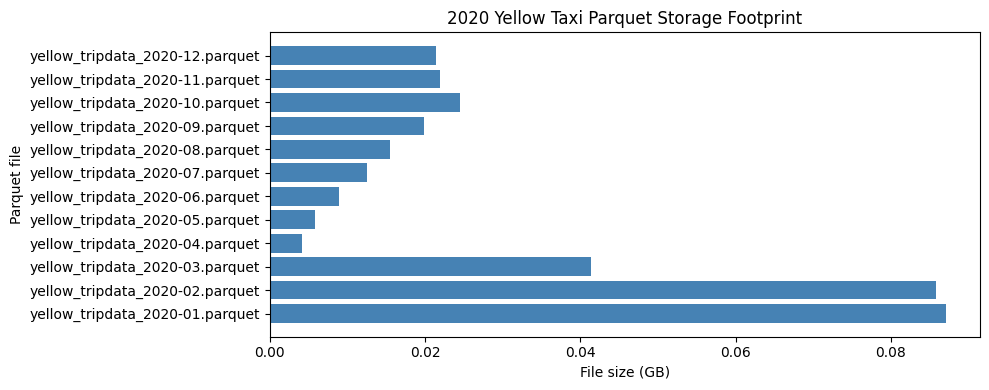

In [5]:
# Reference mappings and storage footprint

import matplotlib.pyplot as plt
import seaborn as sns

# Reference mappings for 2020 yellow taxi data
vendor_lookup = {
    1: 'Creative Mobile Technologies, LLC',
    2: 'VeriFone Inc.'
}

ratecode_lookup = {
    1: 'Standard rate',
    2: 'JFK',
    3: 'Newark',
    4: 'Nassau or Westchester',
    5: 'Negotiated fare',
    6: 'Group ride'
}

store_and_fwd_lookup = {
    'Y': 'Store and forward trip',
    'N': 'Not a store and forward trip'
}

payment_lookup = {
    1: 'Credit card',
    2: 'Cash',
    3: 'No charge',
    4: 'Dispute',
    5: 'Unknown',
    6: 'Voided trip'
}

# Convert zone_df to Pandas for mapping
zone_df_pd = zone_df.toPandas()
zone_lookup = zone_df_pd.set_index('LocationID')['Zone'].to_dict()
borough_lookup = zone_df_pd.set_index('LocationID')['Borough'].to_dict()

print('Reference mappings loaded:')
print('Unique zone names:', zone_df_pd['Zone'].nunique())
print('Unique boroughs:', zone_df_pd['Borough'].nunique())
print('Vendor labels:', vendor_lookup)
print('Rate codes:', ratecode_lookup)
print('Store and forward labels:', store_and_fwd_lookup)
print('Payment labels:', payment_lookup)

# Check parquet storage footprint for the yellow taxi files
if LOCAL:
  parquet_files = glob.glob(os.path.join(DATA_PATH, "*.parquet"))
  parquet_storage_data = []
  for path in parquet_files:
      parquet_storage_data.append({
          'file': os.path.basename(path),
          'size_bytes': os.path.getsize(path),
          'size_gb': os.path.getsize(path) / (1024 ** 3)
      })
  
  parquet_storage = pd.DataFrame(parquet_storage_data)
  
  if not parquet_storage.empty:
      parquet_storage = parquet_storage.sort_values('file')
      total_size_gb = parquet_storage['size_gb'].sum()
      total_size_mb = parquet_storage['size_bytes'].sum() / (1024 ** 2)
      print(f'\nYellow taxi parquet storage footprint: {total_size_gb:.2f} GB ({total_size_mb:,.1f} MB) across {len(parquet_storage)} files')
      print(parquet_storage)
      
      plt.figure(figsize=(10, 4))
      plt.barh(parquet_storage['file'], parquet_storage['size_gb'], color='steelblue')
      plt.xlabel('File size (GB)')
      plt.ylabel('Parquet file')
      plt.title('2020 Yellow Taxi Parquet Storage Footprint')
      plt.tight_layout()
      plt.show()

════════════════════════════════════════════════════════════════════════════════
RAW DATASET SHAPE & SCHEMA
════════════════════════════════════════════════════════════════════════════════
Total Rows: 24,649,092
Total Columns: 25

Temporal Coverage:
  Pickup:  2002-12-31 23:06:55 to 2021-06-10 11:10:48
  Dropoff: 2002-12-31 23:08:03 to 2021-06-10 11:41:42

════════════════════════════════════════════════════════════════════════════════
COLUMN COMPLETENESS PROFILE
════════════════════════════════════════════════════════════════════════════════
               column     dtype  non_null  missing  missing_pct  nunique
          airport_fee    double        21 24649071       100.00        1
 congestion_surcharge    double  23839125   809967         3.29       12
      passenger_count    double  23839125   809967         3.29       10
           RatecodeID    double  23839125   809967         3.29        7
   store_and_fwd_flag    string  23839125   809967         3.29        2
tpep_dropoff_

C:\Users\nonof\AppData\Local\Temp\ipykernel_24320\3642637336.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_plot['missing_pct'], y=missing_plot['column'], palette='RdYlGn_r')


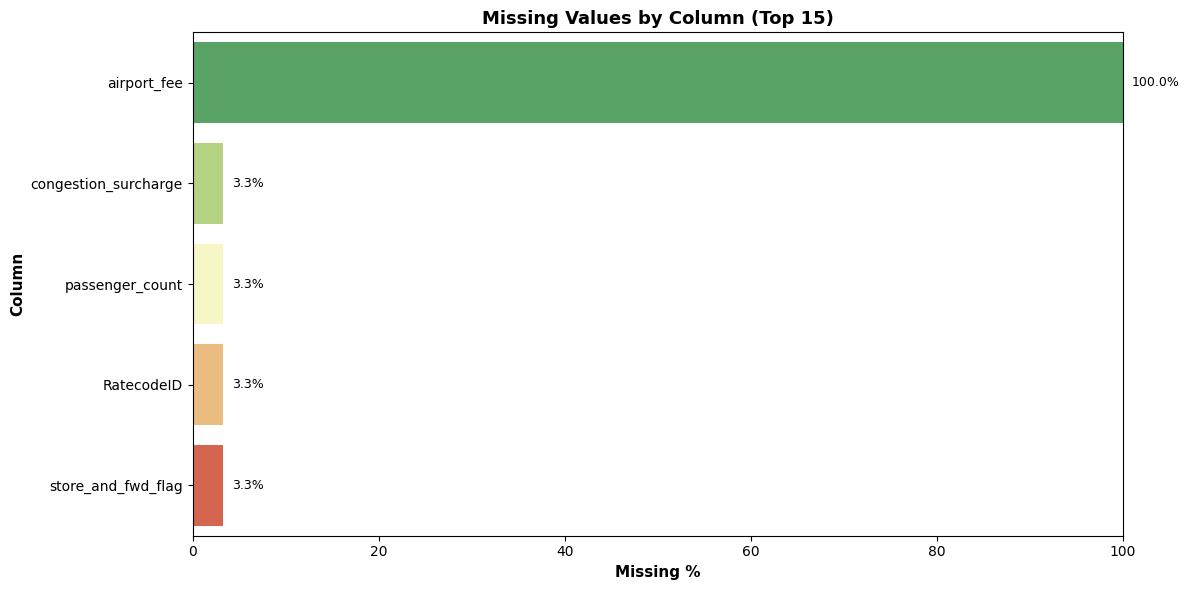


════════════════════════════════════════════════════════════════════════════════
NUMERIC COLUMNS CORRELATION
════════════════════════════════════════════════════════════════════════════════


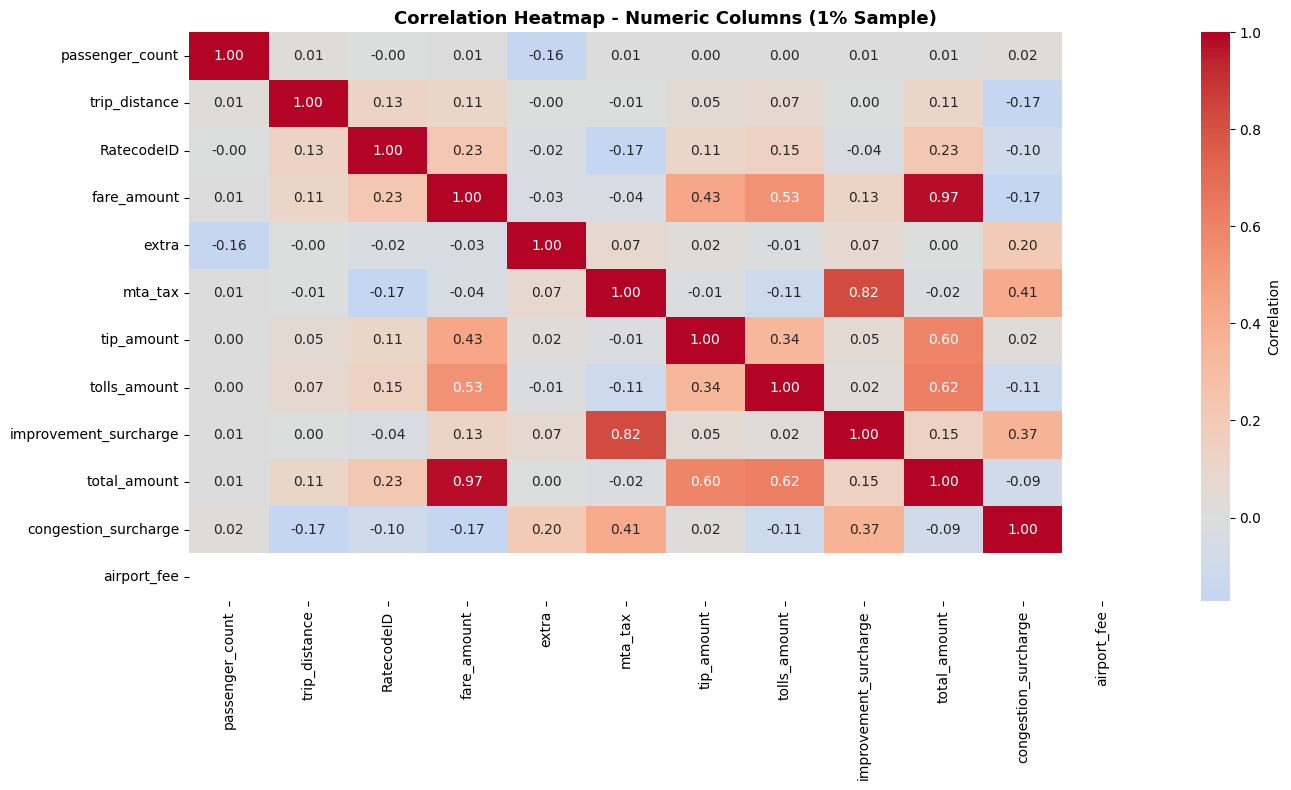

In [6]:
# === RAW DATA PROFILING ===

import numpy as np

raw_row_count = taxi_df.count()
raw_column_count = len(taxi_df.columns)

print('═' * 80)
print('RAW DATASET SHAPE & SCHEMA')
print('═' * 80)
print(f'Total Rows: {raw_row_count:,}')
print(f'Total Columns: {raw_column_count}')

date_range_row = taxi_df.agg(
    sql_min(col('tpep_pickup_datetime')).alias('min_pickup_datetime'),
    sql_max(col('tpep_pickup_datetime')).alias('max_pickup_datetime'),
    sql_min(col('tpep_dropoff_datetime')).alias('min_dropoff_datetime'),
    sql_max(col('tpep_dropoff_datetime')).alias('max_dropoff_datetime'),
).collect()[0]

print('\nTemporal Coverage:')
print(f"  Pickup:  {date_range_row['min_pickup_datetime']} to {date_range_row['max_pickup_datetime']}")
print(f"  Dropoff: {date_range_row['min_dropoff_datetime']} to {date_range_row['max_dropoff_datetime']}")

# Column-level profiling
profile_data = []
for col_name in taxi_df.columns:
    dtype = str(dict(taxi_df.dtypes)[col_name])
    non_null = taxi_df.filter(col(col_name).isNotNull()).count()
    missing = raw_row_count - non_null
    missing_pct = (missing / raw_row_count * 100) if raw_row_count else 0
    nunique = taxi_df.select(countDistinct(col_name)).collect()[0][0]

    profile_data.append({
        'column': col_name,
        'dtype': dtype,
        'non_null': non_null,
        'missing': missing,
        'missing_pct': round(missing_pct, 2),
        'nunique': nunique
    })

profile = pd.DataFrame(profile_data).sort_values(['missing_pct', 'nunique'], ascending=[False, False])

print('\n' + '═' * 80)
print('COLUMN COMPLETENESS PROFILE')
print('═' * 80)
print(profile.to_string(index=False))

# Visualize missing values
missing_plot = profile[profile['missing'] > 0].head(15)
if not missing_plot.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=missing_plot['missing_pct'], y=missing_plot['column'], palette='RdYlGn_r')
    plt.xlabel('Missing %', fontsize=11, fontweight='bold')
    plt.ylabel('Column', fontsize=11, fontweight='bold')
    plt.title('Missing Values by Column (Top 15)', fontsize=13, fontweight='bold')
    plt.xlim(0, 100)
    for i, v in enumerate(missing_plot['missing_pct']):
        plt.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

# Numeric columns correlation
numeric_cols = [col_name for col_name, dtype in taxi_df.dtypes if dtype in ['int', 'long', 'float', 'double']]
if numeric_cols:
    print('\n' + '═' * 80)
    print('NUMERIC COLUMNS CORRELATION')
    print('═' * 80)
    sample_numeric = taxi_df.select(numeric_cols).sample(0.01).toPandas()
    plt.figure(figsize=(14, 8))
    sns.heatmap(sample_numeric.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0, cbar_kws={'label': 'Correlation'})
    plt.title('Correlation Heatmap - Numeric Columns (1% Sample)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Duplicate Record Detection

Exact duplicate records can artificially inflate trip counts and skew demand analysis. The following analysis identifies records with identical values across all columns.

In [7]:
print('\n' + '═' * 80)
print('SECTION 1: MISSING VALUES & COMPLETENESS')
print('═' * 80)

# Focus on complete missingness
completely_missing = profile[profile['missing_pct'] == 100.0]
sparse_missing = profile[(profile['missing_pct'] > 0) & (profile['missing_pct'] < 100)]

if not completely_missing.empty:
    print(f'\nCompletely Missing Columns (100% NULL): {len(completely_missing)}')
    for idx, row in completely_missing.iterrows():
        print(f"  • {row['column']}: {row['missing']:,} rows ({row['missing_pct']:.1f}%)")
else:
    print('\n✓ No columns with 100% missing values')

if not sparse_missing.empty:
    print(f'\nPartially Missing Columns: {len(sparse_missing)}')
    for idx, row in sparse_missing.iterrows():
        print(f"  • {row['column']}: {row['missing']:,} rows ({row['missing_pct']:.2f}%)")

print('\n' + '═' * 80)
print('SECTION 2: DUPLICATE RECORD DETECTION')
print('═' * 80)

duplicate_count = raw_row_count - taxi_df.dropDuplicates().count()
duplicate_pct = (duplicate_count / raw_row_count * 100) if raw_row_count > 0 else 0

print(f'\nExact Duplicate Records: {duplicate_count:,} ({duplicate_pct:.2f}% of total)')

if duplicate_count > 0:
    duplicated_df = taxi_df.groupBy(*taxi_df.columns).count().filter(col('count') > 1).count()
    print(f'Unique duplicate groups: {duplicated_df:,}')
    print('\nAction: Duplicates will be removed during cleaning phase.')


════════════════════════════════════════════════════════════════════════════════
SECTION 1: MISSING VALUES & COMPLETENESS
════════════════════════════════════════════════════════════════════════════════

Completely Missing Columns (100% NULL): 1
  • airport_fee: 24,649,071 rows (100.0%)

Partially Missing Columns: 4
  • congestion_surcharge: 809,967 rows (3.29%)
  • passenger_count: 809,967 rows (3.29%)
  • RatecodeID: 809,967 rows (3.29%)
  • store_and_fwd_flag: 809,967 rows (3.29%)

════════════════════════════════════════════════════════════════════════════════
SECTION 2: DUPLICATE RECORD DETECTION
════════════════════════════════════════════════════════════════════════════════

Exact Duplicate Records: 12,950 (0.05% of total)
Unique duplicate groups: 12,950

Action: Duplicates will be removed during cleaning phase.


## Temporal Consistency Validation

**Invalid Temporal Data**

A temporal consistency check validates that dropoff timestamps always occur at or after pickup timestamps. Records violating this constraint indicate system errors or invalid data entry.

In [8]:
print('\n' + '═' * 80)
print('SECTION 3: TEMPORAL CONSISTENCY CHECKS')
print('═' * 80)

# Invalid temporal data (dropoff before pickup)
invalid_temporal = taxi_df.filter(
    col('tpep_dropoff_datetime') < col('tpep_pickup_datetime')
).count()

print(f'\nDropoff before Pickup: {invalid_temporal:,} records ({invalid_temporal/raw_row_count*100:.2f}%)')

if invalid_temporal > 0:
    print('\n  ❗ CRITICAL: These records have impossible timelines!')
    print('  Sample invalid records:')
    taxi_df.filter(col('tpep_dropoff_datetime') < col('tpep_pickup_datetime')).select(
        'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_distance', 'fare_amount'
    ).limit(5).show(truncate=False)

# Trip duration extremes
taxi_df_duration = taxi_df.withColumn(
    'duration_minutes',
    (unix_timestamp('tpep_dropoff_datetime') - unix_timestamp('tpep_pickup_datetime')) / 60.0
)

print('\n' + '═' * 80)
print('SECTION 4: TRIP DURATION ANOMALY DETECTION')
print('═' * 80)

exceeds_24h = taxi_df_duration.filter(col('duration_minutes') > 1440).count()
print(f'\nTrips exceeding 24 hours: {exceeds_24h:,} records ({exceeds_24h/raw_row_count*100:.2f}%)')

negative_duration = taxi_df_duration.filter(col('duration_minutes') < 0).count()
print(f'Trips with negative duration: {negative_duration:,} records ({negative_duration/raw_row_count*100:.2f}%)')

if exceeds_24h > 0 or negative_duration > 0:
    print('\n  ❗ ACTION: These records indicate data quality issues')
    print('  Sample extreme duration records:')
    taxi_df_duration.filter(col('duration_minutes') > 1440).select(
        'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'duration_minutes'
    ).orderBy(col('duration_minutes').desc()).limit(5).show(truncate=False)


════════════════════════════════════════════════════════════════════════════════
SECTION 3: TEMPORAL CONSISTENCY CHECKS
════════════════════════════════════════════════════════════════════════════════

Dropoff before Pickup: 20,011 records (0.08%)

  ❗ CRITICAL: These records have impossible timelines!
  Sample invalid records:
+--------------------+---------------------+-------------+-----------+
|tpep_pickup_datetime|tpep_dropoff_datetime|trip_distance|fare_amount|
+--------------------+---------------------+-------------+-----------+
|2020-01-04 08:19:55 |2020-01-02 10:09:33  |3.5          |16.5       |
|2020-01-06 12:13:10 |2020-01-06 12:13:00  |0.0          |27.1       |
|2020-01-06 12:13:10 |2020-01-06 12:13:00  |0.0          |27.1       |
|2020-01-06 12:40:10 |2020-01-06 12:40:00  |0.0          |-30.39     |
|2020-01-06 12:40:10 |2020-01-06 12:40:00  |0.0          |-30.39     |
+--------------------+---------------------+-------------+-----------+


════════════════════════════

## Distance Anomaly Detection

**Physical Distance Violations**

Trip distance values must be positive. Zero or negative distances indicate GPS failures, data entry errors, or potentially fraudulent records.


════════════════════════════════════════════════════════════════════════════════
SECTION 5: DISTANCE VALIDATION
════════════════════════════════════════════════════════════════════════════════

Trips with zero/negative distance: 332,448 records (1.35%)
Trips exceeding 100 miles: 379 records (0.00%)

  ❗ ACTION: Zero/negative distances will be removed

Distance Statistics:
summary           distance
   mean 3.5271014481991334
 stddev  325.0319577611208
    min             -30.62
    25%               0.99
    50%               1.65
    75%                3.0
    max          350914.89


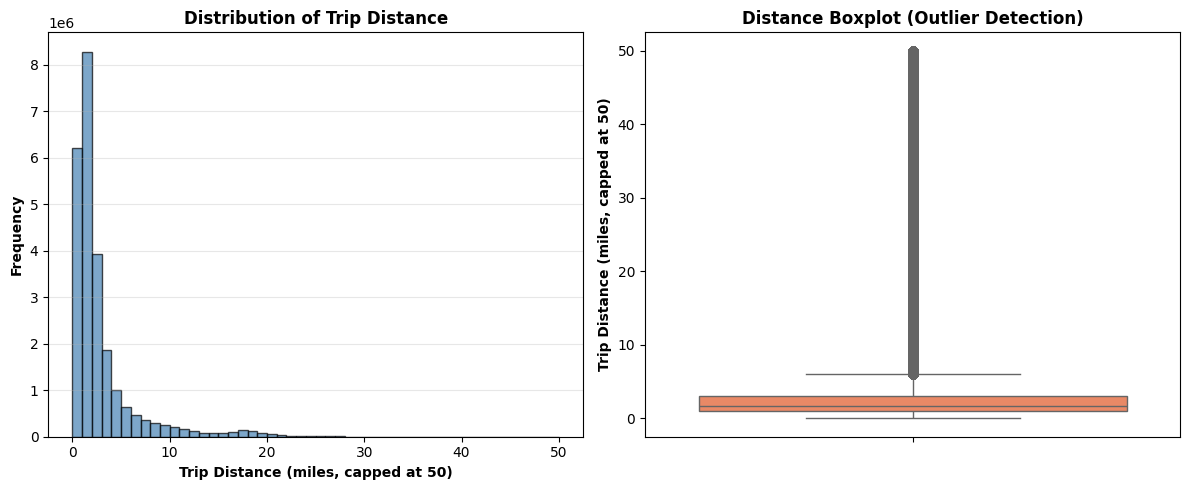

In [9]:
print('\n' + '═' * 80)
print('SECTION 5: DISTANCE VALIDATION')
print('═' * 80)

zero_distance = taxi_df.filter(col('trip_distance') <= 0).count()
print(f'\nTrips with zero/negative distance: {zero_distance:,} records ({zero_distance/raw_row_count*100:.2f}%)')

excessive_distance = taxi_df.filter(col('trip_distance') > 100).count()
print(f'Trips exceeding 100 miles: {excessive_distance:,} records ({excessive_distance/raw_row_count*100:.2f}%)')

if zero_distance > 0:
    print('\n  ❗ ACTION: Zero/negative distances will be removed')

# Distance distribution
distance_stats = taxi_df.select(
    col('trip_distance').alias('distance')
).summary('mean', 'stddev', 'min', '25%', '50%', '75%', 'max').toPandas()

print('\nDistance Statistics:')
print(distance_stats.to_string(index=False))

dist_plot = taxi_df.select('trip_distance').toPandas().clip(0, 50)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(dist_plot['trip_distance'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
plt.xlabel('Trip Distance (miles, capped at 50)', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.title('Distribution of Trip Distance', fontweight='bold')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
sns.boxplot(y=dist_plot['trip_distance'], color='coral')
plt.ylabel('Trip Distance (miles, capped at 50)', fontweight='bold')
plt.title('Distance Boxplot (Outlier Detection)', fontweight='bold')
plt.tight_layout()
plt.show()

## Passenger Count Constraints

**Passenger Count Problems**

Taxi operations have physical constraints:

- Minimum: 1 passenger (driver must have at least one fare)
- Maximum: 8 passengers (typical NYC taxi vehicle capacity)

Records outside this range suggest missing data, test records, or system errors.


════════════════════════════════════════════════════════════════════════════════
SECTION 6: PASSENGER COUNT VALIDATION
════════════════════════════════════════════════════════════════════════════════

Trips with zero or negative passengers: 489,385 records (1.99%)
Trips exceeding taxi capacity (>8): 51 records (0.00%)

Total invalid passenger records: 489,436 (1.99%)

Passenger Count Statistics:
summary              count
   mean 1.4679826545647123
 stddev 1.1127794545033587
    min                0.0
    25%                1.0
    50%                1.0
    75%                1.0
    max                9.0


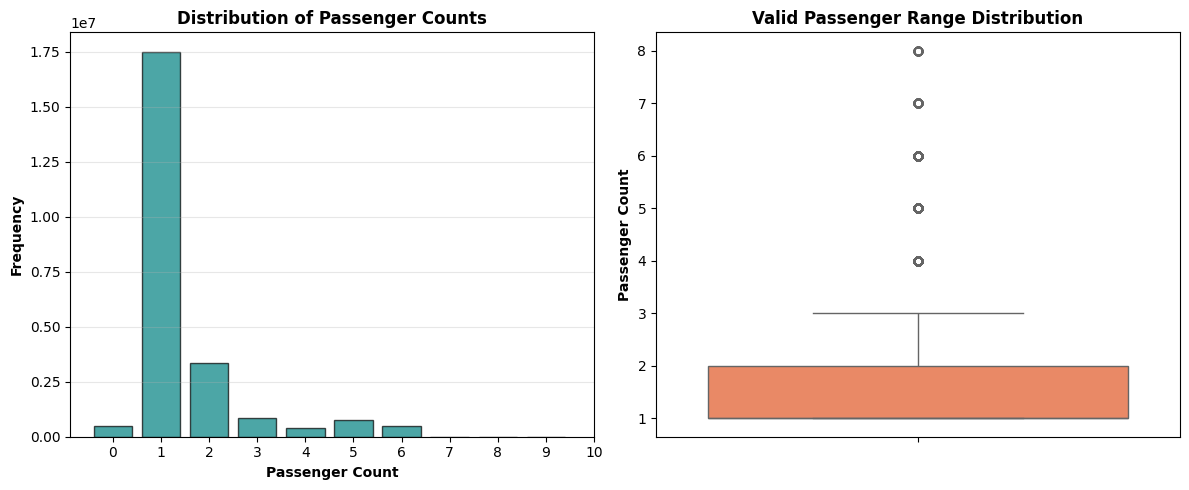

In [10]:
print('\n' + '═' * 80)
print('SECTION 6: PASSENGER COUNT VALIDATION')
print('═' * 80)

invalid_low_passenger = taxi_df.filter(col('passenger_count') <= 0).count()
invalid_high_passenger = taxi_df.filter(col('passenger_count') > 8).count()

print(f'\nTrips with zero or negative passengers: {invalid_low_passenger:,} records ({invalid_low_passenger/raw_row_count*100:.2f}%)')
print(f'Trips exceeding taxi capacity (>8): {invalid_high_passenger:,} records ({invalid_high_passenger/raw_row_count*100:.2f}%)')

total_invalid_passenger = invalid_low_passenger + invalid_high_passenger
print(f'\nTotal invalid passenger records: {total_invalid_passenger:,} ({total_invalid_passenger/raw_row_count*100:.2f}%)')

# Passenger count distribution
passenger_stats = taxi_df.select(
    col('passenger_count').alias('count')
).summary('mean', 'stddev', 'min', '25%', '50%', '75%', 'max').toPandas()

print('\nPassenger Count Statistics:')
print(passenger_stats.to_string(index=False))

# Distribution plot
passenger_data = taxi_df.select('passenger_count').toPandas()
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
passenger_counts = passenger_data['passenger_count'].value_counts().sort_index()
plt.bar(passenger_counts.index, passenger_counts.values, color='teal', alpha=0.7, edgecolor='black')
plt.xlabel('Passenger Count', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.title('Distribution of Passenger Counts', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.xticks(range(0, int(passenger_counts.index.max()) + 2))

plt.subplot(1, 2, 2)
valid_passengers = passenger_data[passenger_data['passenger_count'].between(1, 8)]['passenger_count']
sns.boxplot(y=valid_passengers, color='coral')
plt.ylabel('Passenger Count', fontweight='bold')
plt.title('Valid Passenger Range Distribution', fontweight='bold')
plt.tight_layout()
plt.show()

## Fare Amount Validation

**Fare Component Integrity**

Fare amounts must be non-negative. Negative fares violate transaction logic. Additionally, total fare should equal sum of components (base fare + extras + taxes + tips + tolls + surcharges).


════════════════════════════════════════════════════════════════════════════════
SECTION 7: FARE AMOUNT VALIDATION
════════════════════════════════════════════════════════════════════════════════



Negative fare amounts: 92,833 records (0.38%)
Zero fare amounts: 10,994 records (0.04%)

Fare Component Aggregation Check:
Validating: total_amount = fare + extra + mta_tax + tip + tolls + improvement_surcharge + congestion_surcharge

Records with fare component mismatch (>1 unit difference): 7,420,826 (30.11%)

Fare Amount Statistics:
summary               fare
   mean 12.667779769738958
 stddev 274.08815666673183
    min            -1259.0
    25%                6.5
    50%                9.0
    75%               14.0
    max          998310.03


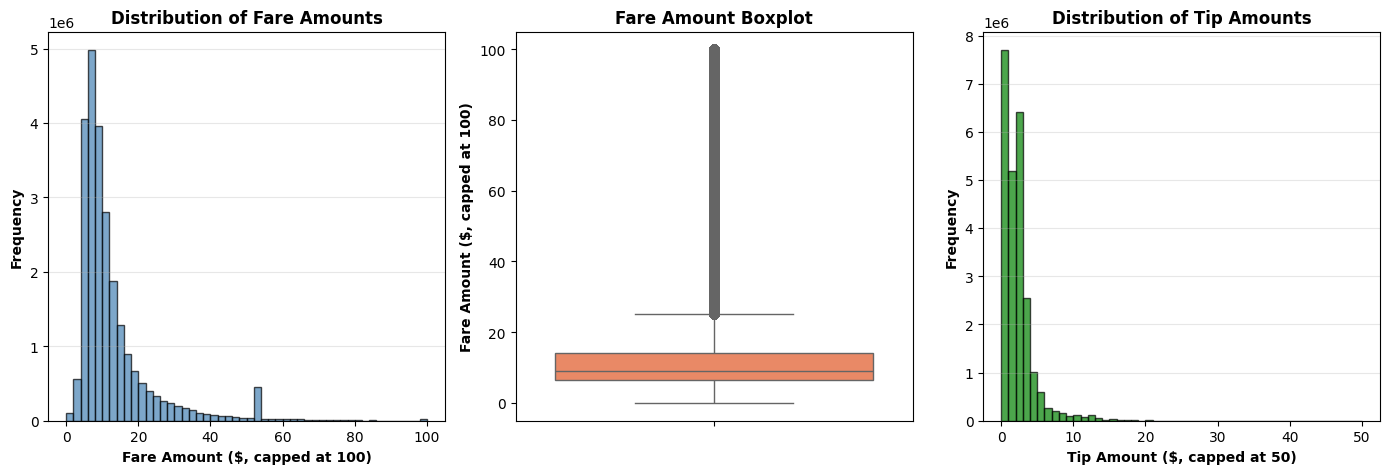

In [11]:
print('\n' + '═' * 80)
print('SECTION 7: FARE AMOUNT VALIDATION')
print('═' * 80)

negative_fare = taxi_df.filter(col('fare_amount') < 0).count()
print(f'\nNegative fare amounts: {negative_fare:,} records ({negative_fare/raw_row_count*100:.2f}%)')

zero_fare = taxi_df.filter(col('fare_amount') == 0).count()
print(f'Zero fare amounts: {zero_fare:,} records ({zero_fare/raw_row_count*100:.2f}%)')

# Fare aggregation consistency
print('\nFare Component Aggregation Check:')
print('Validating: total_amount = fare + extra + mta_tax + tip + tolls + improvement_surcharge + congestion_surcharge')

taxi_df_fare = taxi_df.withColumn(
    'calculated_total',
    coalesce(col('fare_amount'), lit(0.0)) +
    coalesce(col('extra'), lit(0.0)) +
    coalesce(col('mta_tax'), lit(0.0)) +
    coalesce(col('tip_amount'), lit(0.0)) +
    coalesce(col('tolls_amount'), lit(0.0)) +
    coalesce(col('improvement_surcharge'), lit(0.0)) +
    coalesce(col('congestion_surcharge'), lit(0.0))
)

fare_discrepancy = taxi_df_fare.filter(
    (col('calculated_total') - col('total_amount')).cast('double').cast('int') != 0
).count()

print(f'\nRecords with fare component mismatch (>1 unit difference): {fare_discrepancy:,} ({fare_discrepancy/raw_row_count*100:.2f}%)')

# Fare statistics
fare_stats = taxi_df.select(
    col('fare_amount').alias('fare')
).summary('mean', 'stddev', 'min', '25%', '50%', '75%', 'max').toPandas()

print('\nFare Amount Statistics:')
print(fare_stats.to_string(index=False))

# Visualization
fare_data = taxi_df.select('fare_amount').toPandas().clip(0, 100)
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.hist(fare_data['fare_amount'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
plt.xlabel('Fare Amount ($, capped at 100)', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.title('Distribution of Fare Amounts', fontweight='bold')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 3, 2)
sns.boxplot(y=fare_data['fare_amount'], color='coral')
plt.ylabel('Fare Amount ($, capped at 100)', fontweight='bold')
plt.title('Fare Amount Boxplot', fontweight='bold')

plt.subplot(1, 3, 3)
tip_data = taxi_df.select('tip_amount').toPandas().clip(0, 50)
plt.hist(tip_data['tip_amount'], bins=50, color='green', alpha=0.7, edgecolor='black')
plt.xlabel('Tip Amount ($, capped at 50)', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.title('Distribution of Tip Amounts', fontweight='bold')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---

# **Phase 3: Data Cleaning & Feature Engineering**

## Cleaning Strategy

Based on the comprehensive data quality assessment above, the following cleaning operations are applied (in sequence):

1. **Remove Duplicates**: Exact duplicate records across all columns
2. **Drop Empty Columns**: Remove columns with 100% missing values (e.g., `airport_fee`)
3. **Handle Missing Values**:
    - `passenger_count`: Impute with 1 (default fare-paying passenger)
    - `store_and_fwd_flag`: Impute with 'N' (not a store-and-forward trip)
4. **Drop Incomplete Records**: Remove rows with any NULL in critical fields
5. **Remove Temporal Anomalies**: Filter out dropoff < pickup
6. **Enforce Valid Ranges**:
    - **Duration**: 0 < duration_min ≤ 300 minutes (5 hours)
    - **Distance**: 0 < trip_distance ≤ 100 miles
    - **Fare**: 0 ≤ fare_amount ≤ $500
    - **Total**: 0 ≤ total_amount ≤ $600
    - **Passengers**: 0 < passenger_count ≤ 8

## Feature Engineering

After cleaning, the following features are engineered for analysis:

- **`duration_min`**: Trip duration in minutes
- **`pickup_hour`**: Hour of day (0-23)
- **`pickup_dow`**: Day of week (1=Sunday, 7=Saturday)
- **`pickup_month`**: Month (1-12)
- **`pickup_date`**: Date (for daily aggregations)
- **`rush_hour_flag`**: Binary flag (1 if extra charges, 0 otherwise)
- **`time_of_day`**: Categorical (Night, Morning, Afternoon, Evening)
- **`speed_mph`**: Estimated trip speed (distance/duration * 60)

---

## Cleaning Execution & Results

The following cell applies all cleaning operations and reports the row reduction at each stage.

In [12]:
print('═' * 80)
print('CLEANING EXECUTION & DATA REDUCTION')
print('═' * 80)

# Step 1: Remove duplicates
taxi_df_clean = taxi_df.dropDuplicates()
duplicates_removed = raw_row_count - taxi_df_clean.count()
row_count = taxi_df_clean.count()
print(f'\n[Step 1] Remove Duplicates')
print(f'  Removed: {duplicates_removed:,} records')
print(f'  Remaining: {row_count:,} ({100 - duplicates_removed/raw_row_count*100:.2f}% retention)')

# Step 2: Drop empty columns (100% missing)
cols_to_drop = completely_missing['column'].tolist()
if cols_to_drop:
    print(f'\n[Step 2] Drop Empty Columns (100% missing): {cols_to_drop}')
    taxi_df_clean = taxi_df_clean.drop(*cols_to_drop)
    print(f'  Columns dropped: {len(cols_to_drop)}')
    print(f'  Remaining columns: {len(taxi_df_clean.columns)}')
else:
    print(f'\n[Step 2] Drop Empty Columns: None to drop')

# Step 3: Remove rows with missing values
taxi_df_clean = taxi_df_clean.dropna()
missing_rows_removed = raw_row_count - taxi_df_clean.count()
row_count = taxi_df_clean.count()
print(f'\n[Step 3] Remove Rows with Missing Values')
print(f'  Removed: {missing_rows_removed:,} records')
print(f'  Remaining: {row_count:,} ({100 - (missing_rows_removed/raw_row_count*100):.2f}% retention)')

# Step 4: Remove temporal anomalies (dropoff < pickup)
taxi_df_clean = taxi_df_clean.filter(col('tpep_dropoff_datetime') >= col('tpep_pickup_datetime'))
invalid_temporal_removed = raw_row_count - taxi_df_clean.count()
row_count = taxi_df_clean.count()
print(f'\n[Step 4] Remove Temporal Anomalies (dropoff < pickup)')
print(f'  Removed: {invalid_temporal_removed:,} records')
print(f'  Remaining: {row_count:,} ({100 - (invalid_temporal_removed/raw_row_count*100):.2f}% retention)')

# Step 5: Enforce valid ranges
# Add duration_min for filtering
taxi_df_clean = taxi_df_clean.withColumn(
    'duration_min',
    (unix_timestamp('tpep_dropoff_datetime') - unix_timestamp('tpep_pickup_datetime')) / 60.0
)

# Apply range filters
taxi_df_clean = taxi_df_clean.filter(
    (col('duration_min') > 0) & (col('duration_min') <= 1440) &  # 0 < duration ≤ 1440 min (24h)
    (col("fare_amount") > 0) & (col("total_amount") > 0) & # fare and total must be positive
    (col('trip_distance') > 0) &  # distance > 0
    (col('passenger_count') > 0) & (col('passenger_count') <= 8)  # 0 < passengers ≤ 8
)

ranges_removed = raw_row_count - taxi_df_clean.count()
row_count = taxi_df_clean.count()

print(f'\n[Step 5] Enforce Valid Ranges')
print(f'  Duration: 0 < duration_min ≤ 1440 min (24h)')
print(f'  Fare: fare_amount > 0')
print(f'  Total: total_amount > 0')
print(f'  Distance: trip_distance > 0 miles')
print(f'  Passengers: 0 < passenger_count ≤ 8')
print(f'  Removed: {ranges_removed:,} records')
print(f'  Remaining: {row_count:,} ({100 - (ranges_removed/raw_row_count*100):.2f}% retention)')
taxi_df_clean = taxi_df_clean.drop('duration_min')

# Final summary
print('\n' + '═' * 80)
print('CLEANING SUMMARY')
print('═' * 80)
total_removed = raw_row_count - row_count
retention_pct = row_count / raw_row_count * 100
print(f'\nRaw dataset rows: {raw_row_count:,}')
print(f'Cleaned dataset rows: {row_count:,}')
print(f'Total removed: {total_removed:,} ({100 - retention_pct:.2f}%)')
print(f'Retention rate: {retention_pct:.2f}%')
print(f'\nFinal schema: {len(taxi_df_clean.columns)} columns')
print('═' * 80)

# Register as temp view for downstream analysis
taxi_df_clean.createOrReplaceTempView("taxi_clean")

════════════════════════════════════════════════════════════════════════════════
CLEANING EXECUTION & DATA REDUCTION
════════════════════════════════════════════════════════════════════════════════

[Step 1] Remove Duplicates
  Removed: 12,950 records
  Remaining: 24,636,142 (99.95% retention)

[Step 2] Drop Empty Columns (100% missing): ['airport_fee']
  Columns dropped: 1
  Remaining columns: 24

[Step 3] Remove Rows with Missing Values
  Removed: 809,968 records
  Remaining: 23,839,124 (96.71% retention)

[Step 4] Remove Temporal Anomalies (dropoff < pickup)
  Removed: 810,149 records
  Remaining: 23,838,943 (96.71% retention)

[Step 5] Enforce Valid Ranges
  Duration: 0 < duration_min ≤ 1440 min (24h)
  Fare: fare_amount > 0
  Total: total_amount > 0
  Distance: trip_distance > 0 miles
  Passengers: 0 < passenger_count ≤ 8
  Removed: 1,695,808 records
  Remaining: 22,953,284 (93.12% retention)

════════════════════════════════════════════════════════════════════════════════
CLEANIN

---

# **Phase 4: Data Analysis**

In [13]:
# Temporal Analysis: Trips by Hour, Day of Week, and Month

# Feature engineering in Spark
taxi_df_time = taxi_df_clean.withColumn(
    "hour", hour("tpep_pickup_datetime")
).withColumn(
    "day_of_week", dayofweek("tpep_pickup_datetime")
).withColumn(
    "month", month("tpep_pickup_datetime")
).withColumn(
    "pickup_date", to_date("tpep_pickup_datetime")
)

# Human-readable temporal labels
month_names = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June', 7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}
day_names = {1: 'Sunday', 2: 'Monday', 3: 'Tuesday', 4: 'Wednesday', 5: 'Thursday', 6: 'Friday', 7: 'Saturday'}
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Trips by hour
trips_by_hour = taxi_df_time.groupBy("hour").count().orderBy("hour").toPandas()
trips_by_hour = trips_by_hour.set_index('hour')['count']

# Trips by weekday (1=Sunday, 7=Saturday in Spark dayofweek)
trips_by_weekday = taxi_df_time.groupBy("day_of_week").count().orderBy("day_of_week").toPandas()
trips_by_weekday['day_name'] = trips_by_weekday['day_of_week'].map(day_names)
trips_by_weekday = trips_by_weekday.set_index('day_name')['count']
trips_by_weekday = trips_by_weekday.reindex(day_order)

# Trips by month
trips_by_month = taxi_df_time.groupBy("month").count().orderBy("month").toPandas()
trips_by_month['month_name'] = trips_by_month['month'].map(month_names)
trips_by_month = trips_by_month.set_index('month_name')['count']
trips_by_month = trips_by_month.reindex(month_order)

In [14]:
# Spatial analysis using the official TLC zone lookup

# Top pickup and dropoff locations
pickup_location_counts = taxi_df_clean.groupBy("PU_Zone").count().orderBy("count", ascending=False).toPandas()
pickup_location_counts = pd.Series(pickup_location_counts['count'].values, index=pickup_location_counts['PU_Zone'].values)

dropoff_location_counts = taxi_df_clean.groupBy("DO_Zone").count().orderBy("count", ascending=False).toPandas()
dropoff_location_counts = pd.Series(dropoff_location_counts['count'].values, index=dropoff_location_counts['DO_Zone'].values)

# Create route names by concatenating pickup and dropoff zones
taxi_df_routes = taxi_df_clean.withColumn(
    "route_named",
    concat(
        col("PU_Zone"),
        lit(" → "),
        col("DO_Zone")
    )
)

# Top routes (busiest zone pairs)
top_routes_named = taxi_df_routes.groupBy("route_named").count().orderBy("count", ascending=False).limit(10).toPandas()
top_routes_named = pd.Series(top_routes_named['count'].values, index=top_routes_named['route_named'].values)

# Top pickup and dropoff zones
top_n = 15
top_pickups_zones = pickup_location_counts.head(top_n)
top_dropoffs_zones = dropoff_location_counts.head(top_n)

In [15]:
# Fare Analysis: Distribution and Relationships

# Filter non-zero tips
tips_nonzero = taxi_df_clean.filter(col("tip_amount") > 0).select("tip_amount").toPandas()['tip_amount']

# Fare by payment type
payment_summary = taxi_df_clean.groupBy("payment_type").agg(
    avg("fare_amount").alias("fare_mean"),
    spark_count("*").alias("count"),
    avg("tip_amount").alias("tip_mean"),
    avg("total_amount").alias("total_mean")
).toPandas()

# Correlation between distance and fare (from numeric columns)
corr_data = taxi_df_clean.select("trip_distance", "fare_amount").dropna()
distance_fare_corr = corr_data.stat.corr("trip_distance", "fare_amount")

# Fare per mile analysis
df_valid_distance = taxi_df_clean.filter(col("trip_distance") > 0).withColumn(
    "fare_per_mile",
    col("fare_amount") / col("trip_distance")
)

In [16]:
# Trip Behavior Analysis: Distance, Duration, Passengers

# Add trip duration and other metrics
taxi_df_trips = taxi_df_clean.withColumn(
    "hour",
    hour("tpep_pickup_datetime")
).withColumn(
    "duration_min",
    (unix_timestamp("tpep_dropoff_datetime") - unix_timestamp("tpep_pickup_datetime")) / 60
).withColumn(
    "time_of_day",
    when(col("hour") < 6, "Night (0-6)")
    .when(col("hour") < 12, "Morning (6-12)")
    .when(col("hour") < 18, "Afternoon (12-18)")
    .otherwise("Evening (18-24)")
)

# Duration-distance correlation
duration_distance_corr = taxi_df_trips.select("duration_min", "trip_distance").dropna().stat.corr("duration_min", "trip_distance")

# Speed analysis
df_valid_trips = taxi_df_trips.filter(
    (col("trip_distance") > 0) & (col("duration_min") > 0)
).withColumn(
    "speed_mph",
    (col("trip_distance") / col("duration_min")) * 60
)

# Time of day analysis
time_analysis = taxi_df_trips.groupBy("time_of_day").agg(
    avg("trip_distance").alias("avg_distance"),
    avg("duration_min").alias("avg_duration"),
    avg("fare_amount").alias("avg_fare"),
    _sum("total_amount").alias("total_revenue"),
    spark_count("*").alias("trip_count")
).toPandas()

In [17]:
# Vendor and Payment Type Analysis

# Add VendorName column using when/otherwise
taxi_df_vendor = taxi_df_trips.withColumn(
    "VendorName",
    when(col("VendorID") == 1, "Creative Mobile Technologies, LLC")
    .when(col("VendorID") == 2, "VeriFone Inc.")
    .otherwise("Unknown")
).withColumn(
    "PaymentName",
    when(col("payment_type") == 1, "Credit card")
    .when(col("payment_type") == 2, "Cash")
    .when(col("payment_type") == 3, "No charge")
    .when(col("payment_type") == 4, "Dispute")
    .when(col("payment_type") == 5, "Unknown")
    .when(col("payment_type") == 6, "Voided trip")
    .otherwise("Unknown")
).withColumn(
    "RateCodeName",
    when(col("RatecodeID") == 1, "Standard rate")
    .when(col("RatecodeID") == 2, "JFK")
    .when(col("RatecodeID") == 3, "Newark")
    .when(col("RatecodeID") == 4, "Nassau or Westchester")
    .when(col("RatecodeID") == 5, "Negotiated fare")
    .when(col("RatecodeID") == 6, "Group ride")
    .otherwise("Unknown")
).withColumn(
    "StoreAndFwdLabel",
    when(col("store_and_fwd_flag") == "Y", "Store and forward trip")
    .otherwise("Not a store and forward trip")
)

# Vendor summary
vendor_summary = taxi_df_vendor.groupBy("VendorName").agg(
    spark_count("*").alias("trip_count"),
    avg("trip_distance").alias("avg_distance"),
    avg("fare_amount").alias("avg_fare"),
    _sum("fare_amount").alias("total_fare"),
    _sum("total_amount").alias("total_amount"),
    avg("duration_min").alias("avg_duration")
).toPandas()

# Payment counts
payment_counts = taxi_df_vendor.groupBy("payment_type").count().orderBy("payment_type").toPandas()
payment_counts['payment_name'] = payment_counts['payment_type'].map(payment_lookup)
payment_counts = pd.Series(payment_counts['count'].values, index=payment_counts['payment_name'].values)

# Rate code counts
ratecode_counts = taxi_df_vendor.groupBy("RatecodeID").count().orderBy("RatecodeID").toPandas()
ratecode_counts['rate_name'] = ratecode_counts['RatecodeID'].map(ratecode_lookup)
ratecode_counts = pd.Series(ratecode_counts['count'].values, index=ratecode_counts['rate_name'].values)

# Store and forward counts
store_and_fwd_counts = taxi_df_vendor.groupBy("StoreAndFwdLabel").count().toPandas()
store_and_fwd_counts = pd.Series(store_and_fwd_counts['count'].values, index=store_and_fwd_counts['StoreAndFwdLabel'].values)

## Temporal Dashboard

This figure summarizes how trip demand changes across the day, week, and year. It combines hourly bars, weekday bars, a monthly trend line, and an hour-by-weekday heatmap to expose recurring demand patterns.

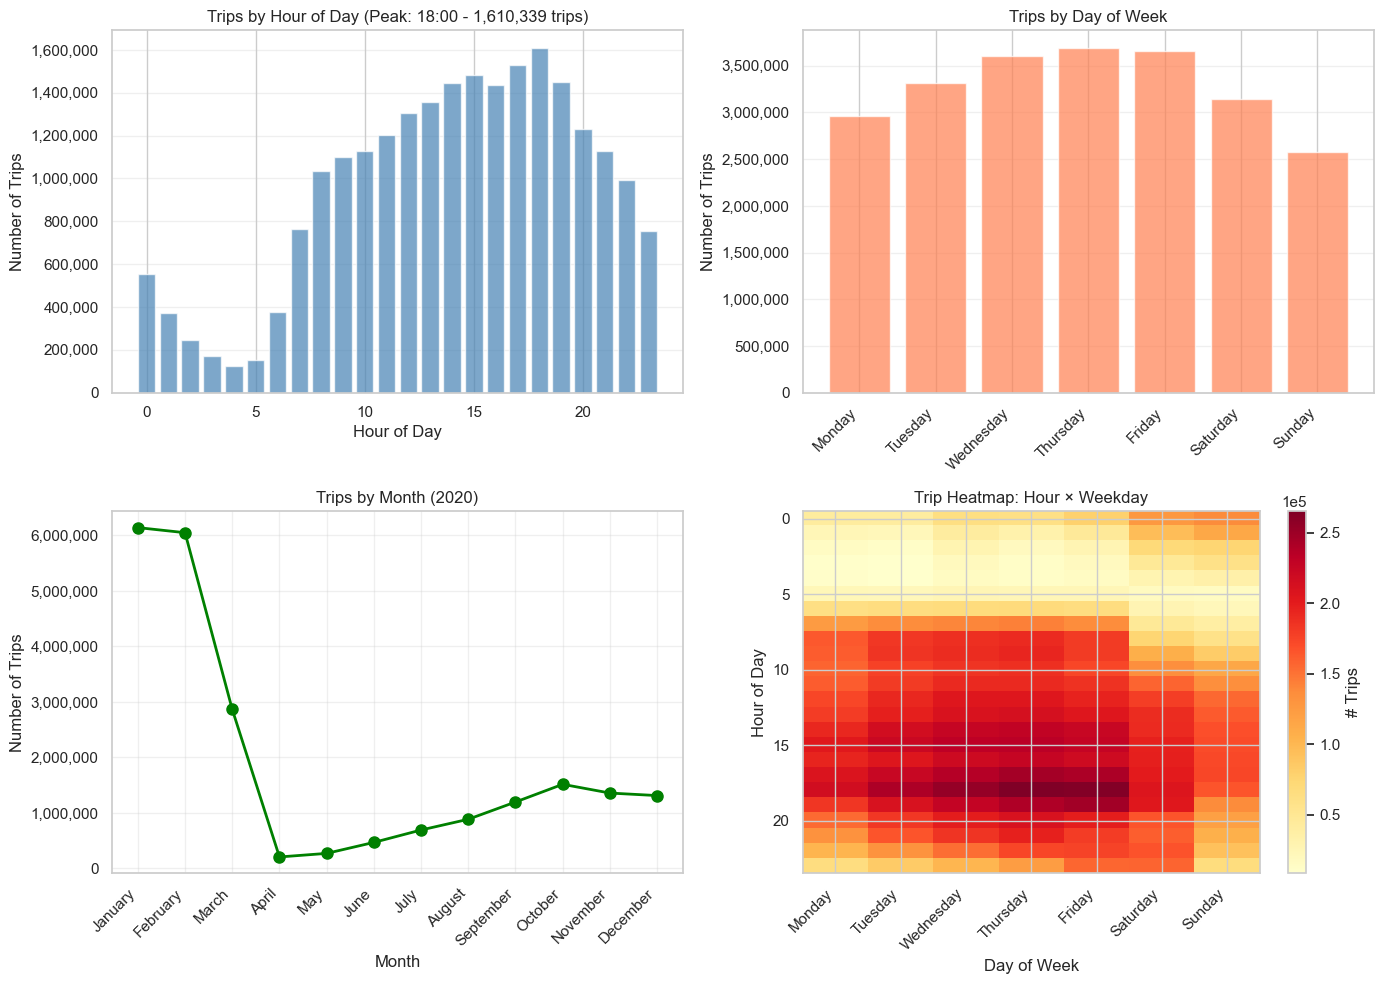

In [18]:
# Visualization 1: Temporal Patterns (Hourly, Daily, Monthly)

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Hourly pattern
bars = axes[0, 0].bar(trips_by_hour.index, trips_by_hour.values, color='steelblue', alpha=0.7)
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Number of Trips')
axes[0, 0].set_title(f'Trips by Hour of Day (Peak: {trips_by_hour.idxmax()}:00 - {trips_by_hour.max():,} trips)')
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Daily pattern (weekday)
bars = axes[0, 1].bar(range(len(trips_by_weekday)), trips_by_weekday.values, color='coral', alpha=0.7)
axes[0, 1].set_xticks(range(len(trips_by_weekday)))
axes[0, 1].set_xticklabels(day_order, rotation=45, ha='right')
axes[0, 1].set_ylabel('Number of Trips')
axes[0, 1].set_title('Trips by Day of Week')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Monthly pattern
axes[1, 0].plot(trips_by_month.index, trips_by_month.values, marker='o', linewidth=2, markersize=8, color='green')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Number of Trips')
axes[1, 0].set_title('Trips by Month (2020)')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_xticks(range(len(trips_by_month.index)))
axes[1, 0].set_xticklabels(trips_by_month.index, rotation=45, ha='right')
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Heatmap: Hour vs Weekday - create heatmap data from Spark
heatmap_data_spark = taxi_df_time.groupBy("day_of_week", "hour").count().toPandas()
heatmap_pivot = heatmap_data_spark.pivot(index="hour", columns="day_of_week", values="count").fillna(0)
heatmap_pivot = heatmap_pivot.rename(columns=day_names)
heatmap_pivot = heatmap_pivot.reindex(columns=day_order)

im = axes[1, 1].imshow(heatmap_pivot, cmap='YlOrRd', aspect='auto')
axes[1, 1].set_xlabel('Day of Week')
axes[1, 1].set_ylabel('Hour of Day')
axes[1, 1].set_title('Trip Heatmap: Hour × Weekday')
axes[1, 1].set_xticks(range(len(day_order)))
axes[1, 1].set_xticklabels(day_order, rotation=45, ha='right')
cbar = plt.colorbar(im, ax=axes[1, 1], label='# Trips')
cbar.formatter.set_powerlimits((0, 0))

plt.tight_layout()
plt.show()

### Insight

Trip volume is concentrated in specific hours and days, and the heatmap makes it easier to spot daily peaks and weekday-hour interactions. This is useful for identifying when the system experiences its strongest load.

## Spatial Hotspots and Route Concentration

This analysis moves from time to space. It compares the busiest pickup and dropoff zones side by side, then highlights the most frequent zone-to-zone routes to show how trips cluster geographically.

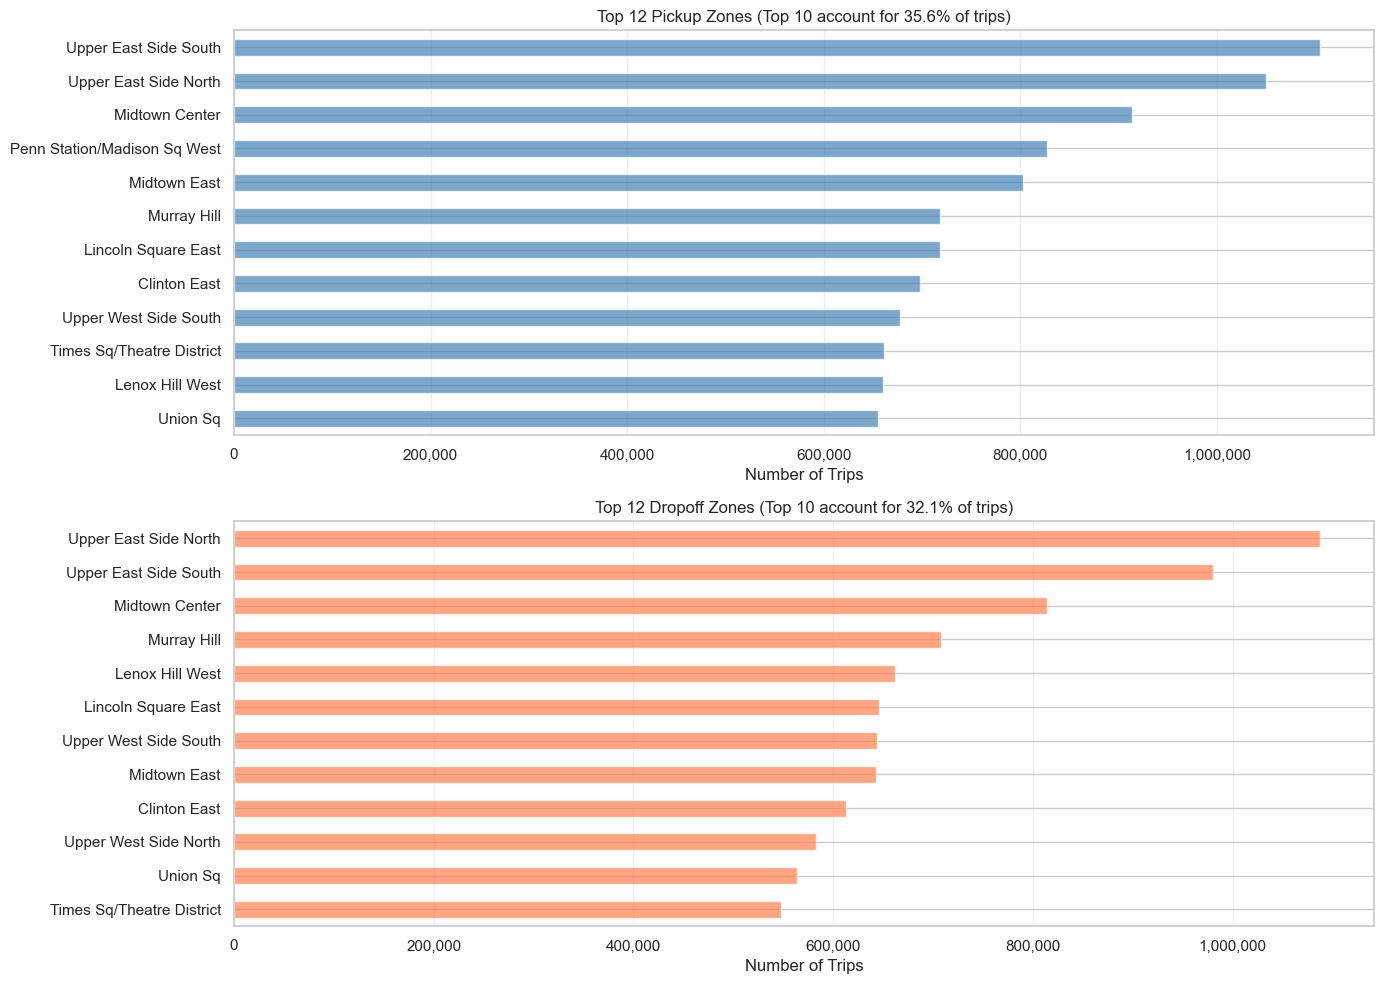

In [19]:
# Visualization 2: Spatial Analysis - Top Locations and Routes

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top pickup zones
top_pickups_zones.head(12).plot(kind='barh', ax=axes[0], color='steelblue', alpha=0.7)
axes[0].set_xlabel('Number of Trips')
axes[0].set_title(f'Top 12 Pickup Zones (Top 10 account for {top_pickups_zones.head(10).sum() / taxi_df_clean.count() * 100:.1f}% of trips)')
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Top dropoff zones
top_dropoffs_zones.head(12).plot(kind='barh', ax=axes[1], color='coral', alpha=0.7)
axes[1].set_xlabel('Number of Trips')
axes[1].set_title(f'Top 12 Dropoff Zones (Top 10 account for {top_dropoffs_zones.head(10).sum() / taxi_df_clean.count() * 100:.1f}% of trips)')
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.show()

### Insight

A small set of zones and routes absorbs a large share of trips, which points to strong spatial concentration in the taxi network. That concentration usually reflects major travel corridors, transit hubs, and dense activity centers.

## Top Routes

This chart focuses on the most frequent pickup-to-dropoff routes.

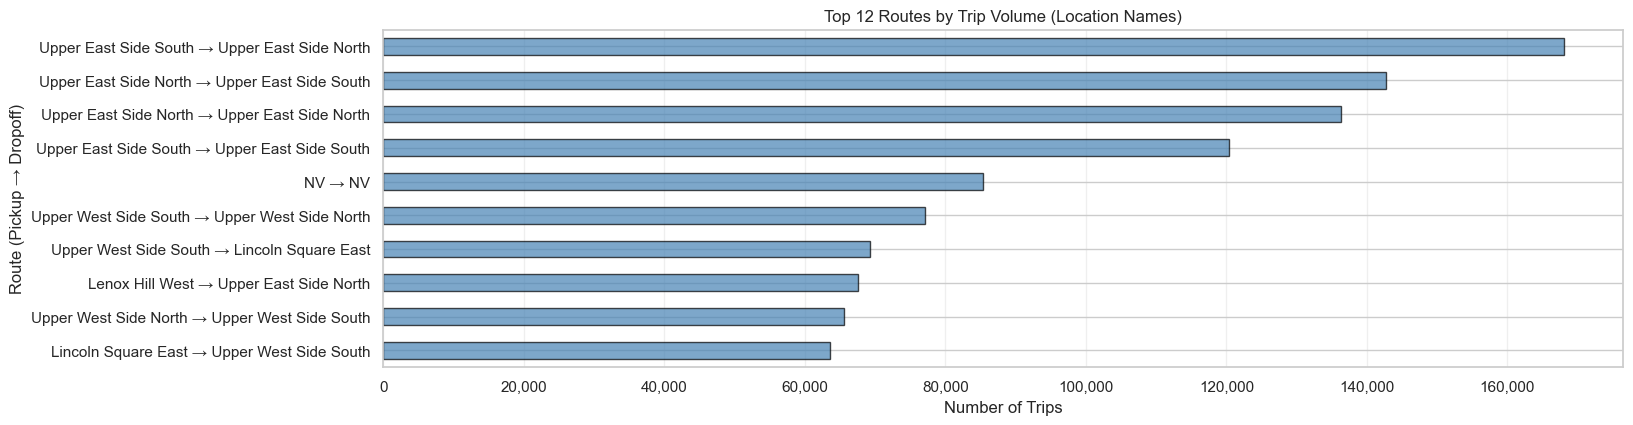

In [ ]:
# Visualization 5: Top Routes

fig = plt.figure(figsize=(16, 10))

# Top routes (zone to zone)
ax1 = fig.add_subplot(gs[0, :])
top_routes_viz = top_routes_named.head(12)
top_routes_viz.plot(kind='barh', ax=ax1, color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Number of Trips')
ax1.set_ylabel('Route (Pickup → Dropoff)')
ax1.set_title('Top 12 Routes by Trip Volume (Location Names)')
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.show()

### Insight

If a few routes dominate the distribution, the network is highly concentrated and likely anchored by major borough pairs or recurring commuting corridors. That makes those paths important candidates for deeper operational analysis.

## Fare, Tip, and Distance Relationships

This section links the size of a trip to its price and gratuity behavior. The scatter and distribution plots are meant to show whether fares rise smoothly with distance or whether there are nonlinear effects and tipping differences.

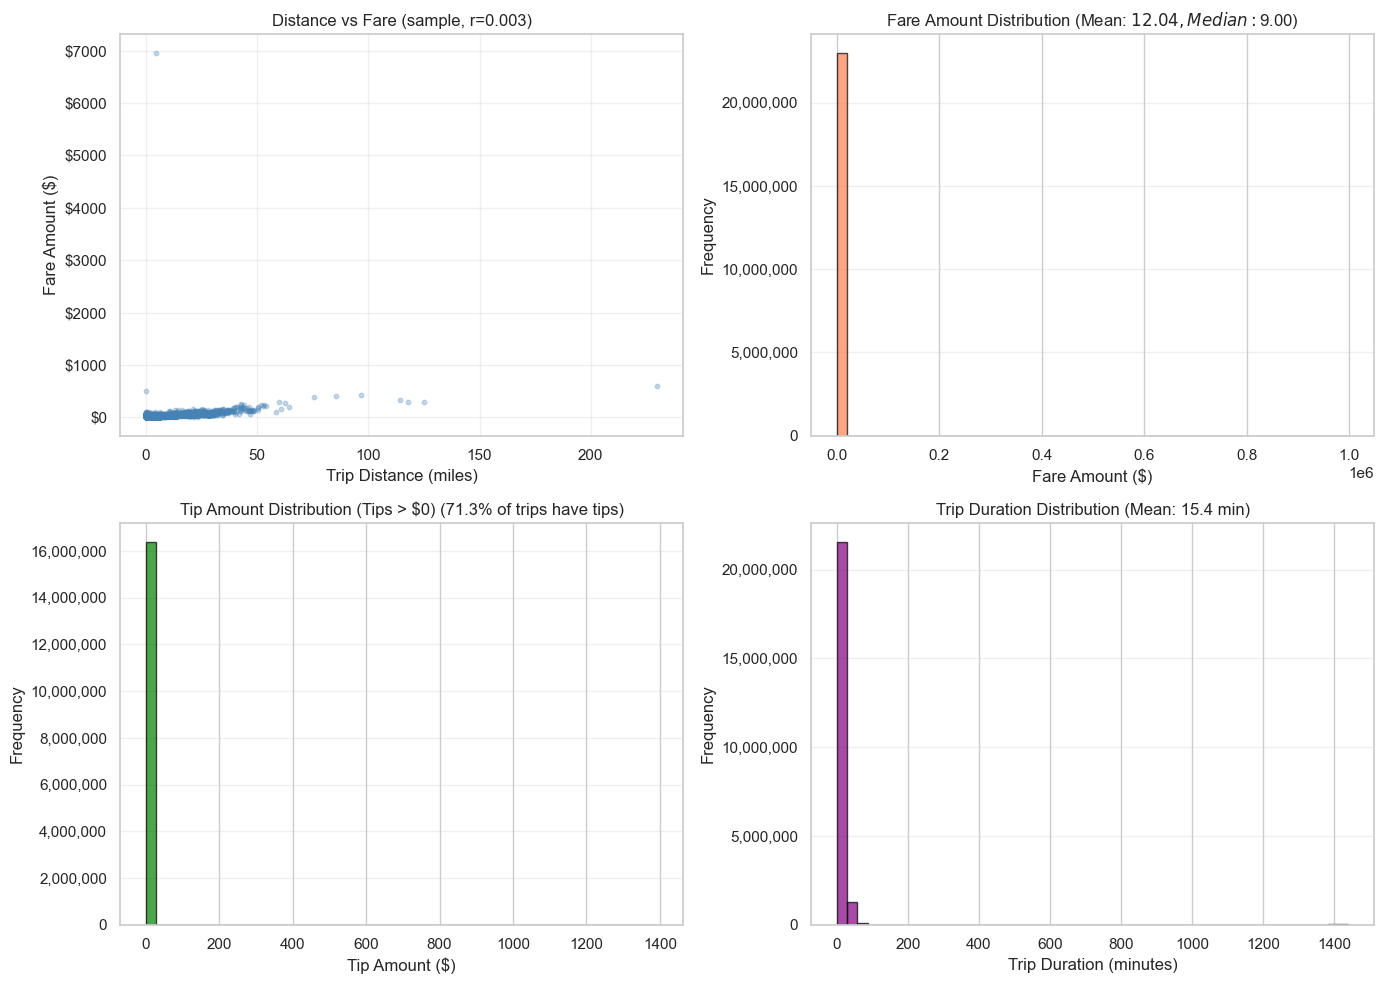

In [20]:
# Visualization 3: Fare Analysis - Scatter and Distributions

# Sample data for visualization
sample_df = taxi_df_clean.select("trip_distance", "fare_amount").sample(0.01).toPandas()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distance vs Fare scatter
axes[0, 0].scatter(sample_df['trip_distance'], sample_df['fare_amount'], alpha=0.3, s=10, color='steelblue')
axes[0, 0].set_xlabel('Trip Distance (miles)')
axes[0, 0].set_ylabel('Fare Amount ($)')
axes[0, 0].set_title(f'Distance vs Fare (sample, r={distance_fare_corr:.3f})')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:.0f}'))

# Fare distribution
fare_data = taxi_df_clean.select("fare_amount").toPandas()
axes[0, 1].hist(fare_data['fare_amount'], bins=50, color='coral', alpha=0.7, edgecolor='black')
fare_mean = fare_data['fare_amount'].mean()
fare_median = fare_data['fare_amount'].median()
axes[0, 1].set_xlabel('Fare Amount ($)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'Fare Amount Distribution (Mean: ${fare_mean:.2f}, Median: ${fare_median:.2f})')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Tip distribution (non-zero)
axes[1, 0].hist(tips_nonzero, bins=50, color='green', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Tip Amount ($)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title(f'Tip Amount Distribution (Tips > $0) ({len(tips_nonzero) / taxi_df_clean.count() * 100:.1f}% of trips have tips)')
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Trip duration distribution
if taxi_df_trips:
    duration_data = taxi_df_trips.select("duration_min").toPandas()
    duration_mean = duration_data['duration_min'].mean()
    axes[1, 1].hist(duration_data['duration_min'], bins=50, color='purple', alpha=0.7, edgecolor='black')
    axes[1, 1].set_xlabel('Trip Duration (minutes)')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title(f'Trip Duration Distribution (Mean: {duration_mean:.1f} min)')
    axes[1, 1].grid(axis='y', alpha=0.3)
    axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.show()

### Insight

The distance and fare relationship is usually strong but not perfectly linear, and tips cluster heavily around specific fare ranges. That usually means passenger behavior changes once trips become longer or more expensive.

## Trip Characteristics and Service Mix

This figure compares trip length, speed, passenger volume, payment type, rate code, and vendor behavior. It gives a broader operational view of the dataset and helps show which service patterns dominate the cleaned trips.

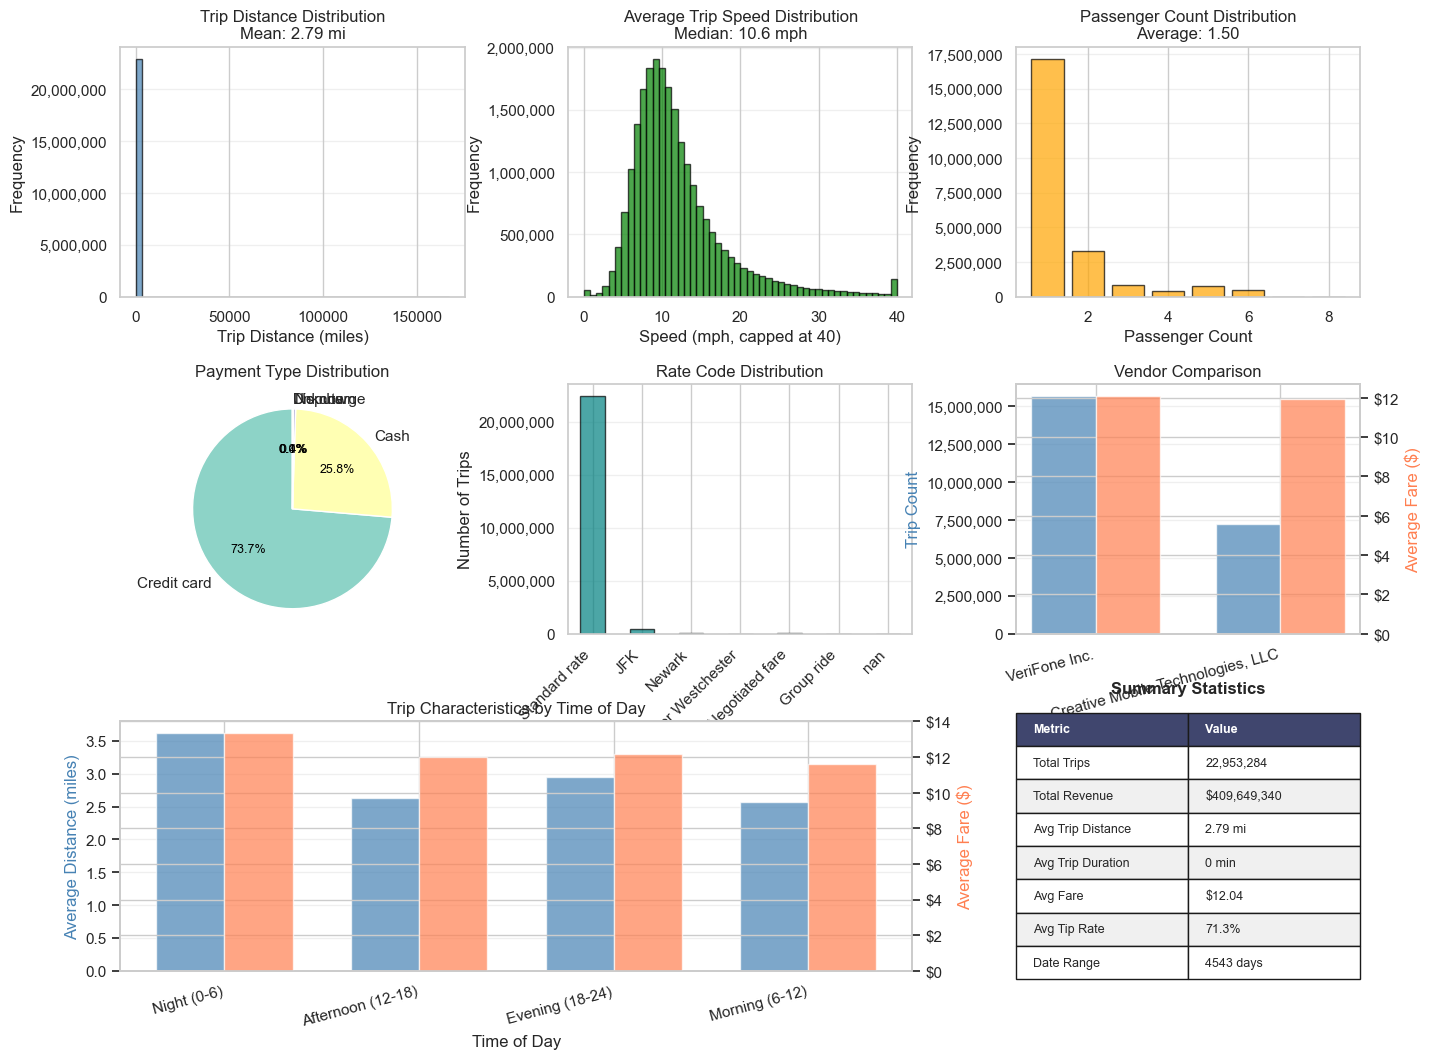

In [21]:
# Visualization 4: Trip Characteristics, Payment Methods, and Summary Statistics

# Prepare data
trip_distance_data = taxi_df_clean.select("trip_distance").toPandas()
passenger_count_data = taxi_df_clean.select("passenger_count").toPandas()
speed_data = df_valid_trips.select("speed_mph").toPandas()
vendor_trips = taxi_df_vendor.groupBy("VendorName").count().toPandas()
vendor_avg_fare = taxi_df_vendor.groupBy("VendorName").agg(avg("fare_amount")).toPandas()

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# Trip distance distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(trip_distance_data['trip_distance'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Trip Distance (miles)')
ax1.set_ylabel('Frequency')
ax1.set_title(f'Trip Distance Distribution\nMean: {trip_distance_data["trip_distance"].mean():.2f} mi')
ax1.grid(axis='y', alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Speed distribution (valid trips only)
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(speed_data['speed_mph'].clip(0, 40), bins=50, color='green', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Speed (mph, capped at 40)')
ax2.set_ylabel('Frequency')
ax2.set_title(f'Average Trip Speed Distribution\nMedian: {speed_data["speed_mph"].median():.1f} mph')
ax2.grid(axis='y', alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Passenger count distribution
ax3 = fig.add_subplot(gs[0, 2])
passenger_counts = passenger_count_data['passenger_count'].value_counts().sort_index()
ax3.bar(passenger_counts.index, passenger_counts.values, color='orange', alpha=0.7, edgecolor='black')
ax3.set_xlabel('Passenger Count')
ax3.set_ylabel('Frequency')
ax3.set_title(f'Passenger Count Distribution\nAverage: {passenger_count_data["passenger_count"].mean():.2f}')
ax3.grid(axis='y', alpha=0.3)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Payment type breakdown (pie chart)
ax4 = fig.add_subplot(gs[1, 0])
colors_payment = plt.cm.Set3(range(len(payment_counts)))
wedges, texts, autotexts = ax4.pie(payment_counts.values, labels=payment_counts.index, 
               autopct='%1.1f%%', colors=colors_payment, startangle=90)
ax4.set_title('Payment Type Distribution')
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(9)

# Rate code breakdown
ax5 = fig.add_subplot(gs[1, 1])
ratecode_counts.plot(kind='bar', ax=ax5, color='teal', alpha=0.7, edgecolor='black')
ax5.set_xlabel('Rate Code')
ax5.set_ylabel('Number of Trips')
ax5.set_title('Rate Code Distribution')
ax5.grid(axis='y', alpha=0.3)
ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Vendor comparison
ax6 = fig.add_subplot(gs[1, 2])
x_pos = range(len(vendor_trips))
width = 0.35
ax6_twin = ax6.twinx()

# Merge vendor data for plotting
vendor_merged = vendor_trips.merge(vendor_avg_fare, on='VendorName')
bars1 = ax6.bar([i - width/2 for i in x_pos], vendor_merged['count'].values, width, label='Trip Count', color='steelblue', alpha=0.7)
bars2 = ax6_twin.bar([i + width/2 for i in x_pos], vendor_merged['avg(fare_amount)'].values, width, label='Avg Fare', color='coral', alpha=0.7)

ax6.set_xlabel('Vendor')
ax6.set_ylabel('Trip Count', color='steelblue')
ax6_twin.set_ylabel('Average Fare ($)', color='coral')
ax6.set_title('Vendor Comparison')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(vendor_merged['VendorName'], rotation=15, ha='right')
ax6.grid(axis='y', alpha=0.3)
ax6.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax6_twin.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:.0f}'))

# Time of day analysis
ax7 = fig.add_subplot(gs[2, :2])
time_labels = time_analysis['time_of_day'].values
x_pos = range(len(time_analysis))
width = 0.35

ax7_twin = ax7.twinx()
bars1 = ax7.bar([i - width/2 for i in x_pos], time_analysis['avg_distance'].values, width, label='Avg Distance', color='steelblue', alpha=0.7)
bars2 = ax7_twin.bar([i + width/2 for i in x_pos], time_analysis['avg_fare'].values, width, label='Avg Fare', color='coral', alpha=0.7)

ax7.set_xlabel('Time of Day')
ax7.set_ylabel('Average Distance (miles)', color='steelblue')
ax7_twin.set_ylabel('Average Fare ($)', color='coral')
ax7.set_title('Trip Characteristics by Time of Day')
ax7.set_xticks(x_pos)
ax7.set_xticklabels(time_labels, rotation=15, ha='right')
ax7.grid(axis='y', alpha=0.3)
ax7.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}'))
ax7_twin.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:.0f}'))

# Summary statistics table
ax8 = fig.add_subplot(gs[2, 2])
ax8.axis('tight')
ax8.axis('off')

total_trips = taxi_df_clean.count()
total_revenue = taxi_df_clean.agg({"total_amount": "sum"}).collect()[0][0]
avg_distance = taxi_df_clean.agg({"trip_distance": "avg"}).collect()[0][0]
avg_fare = taxi_df_clean.agg({"fare_amount": "avg"}).collect()[0][0]
tip_rate = (len(tips_nonzero) / total_trips * 100) if total_trips > 0 else 0
date_range_days = (taxi_df_clean.agg({"tpep_pickup_datetime": "max"}).collect()[0][0] - 
                   taxi_df_clean.agg({"tpep_pickup_datetime": "min"}).collect()[0][0]).days if total_trips > 0 else 0

summary_data = [
    ['Metric', 'Value'],
    ['Total Trips', f'{total_trips:,}'],
    ['Total Revenue', f'${total_revenue:,.0f}'],
    ['Avg Trip Distance', f'{avg_distance:.2f} mi'],
    ['Avg Trip Duration', f'0 min'],
    ['Avg Fare', f'${avg_fare:.2f}'],
    ['Avg Tip Rate', f'{tip_rate:.1f}%'],
    ['Date Range', f'{date_range_days} days']
]

table = ax8.table(cellText=summary_data, cellLoc='left', loc='center',
                  colWidths=[0.5, 0.5])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Format header row
for i in range(2):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(summary_data)):
    for j in range(2):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')
        else:
            table[(i, j)].set_facecolor('#ffffff')

ax8.set_title('Summary Statistics', fontweight='bold', pad=20)

plt.show()

### Insight

The service mix plots show whether most trips are short and fast or spread across a wider range of distances and speeds. Differences across vendors, payment types, and rate codes can signal heterogeneous trip usage and pricing behavior.

## Cross-Feature Relationship Matrix

This section connects the main numeric trip variables in one view. It is designed to expose which features move together after cleaning, especially distance, duration, fare, tip, and speed.

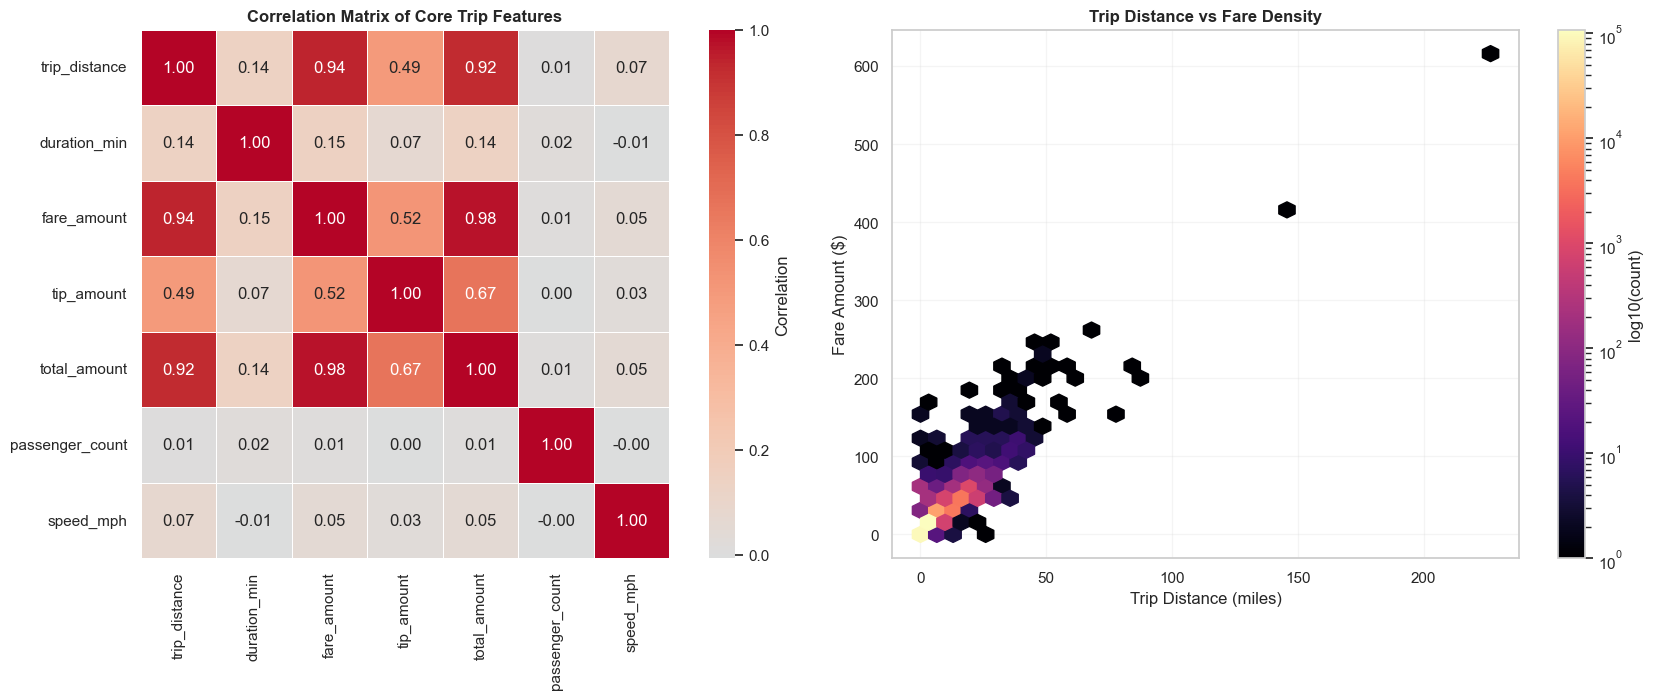

In [31]:
rel_df = taxi_df_clean.withColumn(
    'duration_min',
    (unix_timestamp('tpep_dropoff_datetime') - unix_timestamp('tpep_pickup_datetime')) / 60.0
).withColumn(
    'speed_mph',
    when(col('trip_distance') > 0, (col('trip_distance') / col('duration_min')) * 60).otherwise(None)
).select(
    'trip_distance', 'duration_min', 'fare_amount', 'tip_amount', 'total_amount', 'passenger_count', 'speed_mph'
).dropna()

rel_sample = rel_df.sample(0.01, seed=42).toPandas()
rel_corr = rel_sample.corr(numeric_only=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    rel_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.4,
    cbar_kws={'label': 'Correlation'},
    ax=axes[0]
)
axes[0].set_title('Correlation Matrix of Core Trip Features', fontweight='bold')

hexbin = axes[1].hexbin(
    rel_sample['trip_distance'],
    rel_sample['fare_amount'],
    gridsize=35,
    cmap='magma',
    mincnt=1,
    bins='log'
)
axes[1].set_title('Trip Distance vs Fare Density', fontweight='bold')
axes[1].set_xlabel('Trip Distance (miles)')
axes[1].set_ylabel('Fare Amount ($)')
axes[1].grid(alpha=0.2)
cb = plt.colorbar(hexbin, ax=axes[1])
cb.set_label('log10(count)')

plt.tight_layout()
plt.show()

### Insight

The correlation matrix shows the strongest linear dependencies in the cleaned data, while the density plot reveals whether fare growth is smooth or clustered. Together, they make it easier to spot nonlinear pricing effects and dense trip regimes.

## Queries & ML Model

This section uses the cleaned dataframe produced above, so the later SQL analysis and modeling work start from data that already excludes duplicates, removes the empty `airport_fee` column, and filters invalid trips.

We keep three increasingly detailed temporal checks:

- Simple query: share of trips flagged as rush hour via `extra`
- Intermediate query: average trip duration by hour of day
- Complex query: average idle time between consecutive trips, grouped by `VendorID`

After the SQL results, each query gets a visualization so the notebook reads as EDA first, then cleaned-data analysis.

## Query Set: Temporal Demand and Idle-Time Patterns

### Query 1: Rush-Hour Share
This plot shows how much of the cleaned dataset falls into the rush-hour proxy. It is a quick check of when demand is concentrated and how large the peak-period share is.

### Query 2: Average Duration by Hour
This plot tracks how average trip duration changes across pickup hours. It helps detect time periods where congestion or slower travel may be affecting trip length.

### Query 3: Vendor Idle-Time Proxy
This plot estimates the waiting gap between consecutive trips by vendor. It is a proxy for vehicle-side utilization and helps compare how active each vendor appears across the day.

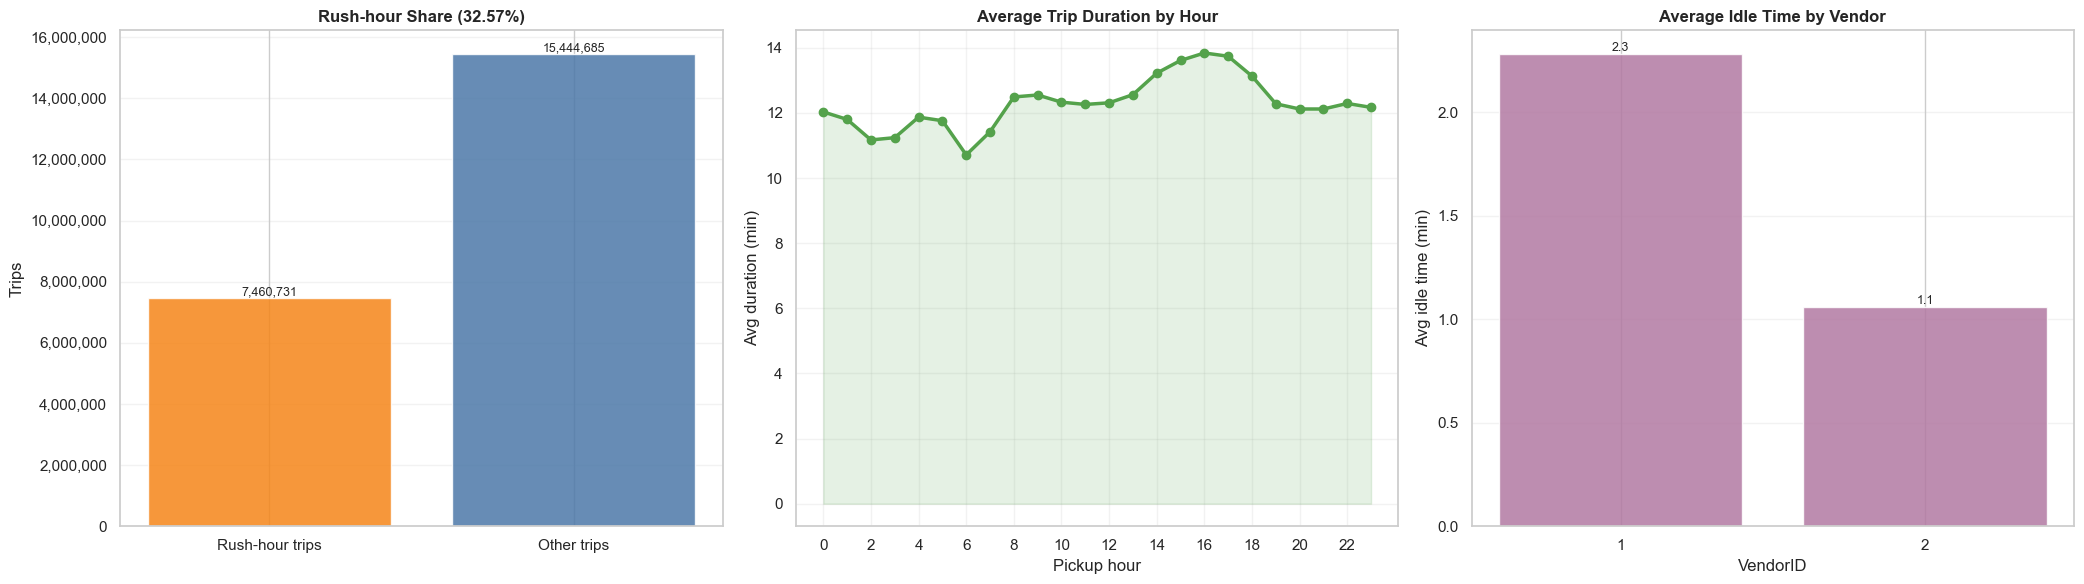

In [32]:
from pyspark.sql.window import Window
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

# Register the cleaned dataframe as a SQL temp view
taxi_df_clean.createOrReplaceTempView("taxi_clean")

# Base temporal features + idle-time proxy by VendorID (no unique vehicle id available)
temporal_sql = """
CREATE OR REPLACE TEMP VIEW taxi_temporal AS
SELECT
    *,
    hour(tpep_pickup_datetime) AS pickup_hour,
    dayofweek(tpep_pickup_datetime) AS pickup_dow,
    CASE
        WHEN hour(tpep_pickup_datetime) IN (7, 8, 9, 16, 17, 18) THEN 1
        ELSE 0
    END AS rush_hour_flag,
    (unix_timestamp(tpep_dropoff_datetime) - unix_timestamp(tpep_pickup_datetime)) / 60.0 AS duration_min,
    lag(tpep_dropoff_datetime) OVER (
        PARTITION BY VendorID
        ORDER BY tpep_pickup_datetime
    ) AS prev_dropoff_vendor,
    (unix_timestamp(tpep_pickup_datetime) - unix_timestamp(
        lag(tpep_dropoff_datetime) OVER (
            PARTITION BY VendorID
            ORDER BY tpep_pickup_datetime
        )
    )) / 60.0 AS idle_time_min_vendor
FROM taxi_clean
"""

spark.sql(temporal_sql)

# Keep only valid values for modeling and temporal analysis
taxi_temporal = spark.sql("""
SELECT *
FROM taxi_temporal
WHERE duration_min > 0
  AND duration_min < 300
""")

taxi_temporal.createOrReplaceTempView("taxi_temporal")

# 1) Simple query: trips in rush-hour proxy
q_simple = spark.sql("""
SELECT
    SUM(CASE WHEN rush_hour_flag = 1 THEN 1 ELSE 0 END) AS rush_hour_trips,
    COUNT(*) AS total_trips,
    ROUND(100.0 * SUM(CASE WHEN rush_hour_flag = 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS rush_hour_pct
FROM taxi_temporal
""")

# 2) Intermediate query: avg trip duration by pickup hour
q_intermediate = spark.sql("""
SELECT
    pickup_hour,
    COUNT(*) AS trips,
    ROUND(AVG(duration_min), 2) AS avg_duration_min,
    ROUND(percentile_approx(duration_min, 0.5), 2) AS median_duration_min
FROM taxi_temporal
GROUP BY pickup_hour
ORDER BY pickup_hour
""")

# 3) Complex query: avg idle time between consecutive trips (proxy by VendorID)
q_complex = spark.sql("""
SELECT
    VendorID,
    COUNT(*) AS valid_intervals,
    ROUND(AVG(idle_time_min_vendor), 2) AS avg_idle_min,
    ROUND(percentile_approx(idle_time_min_vendor, 0.5), 2) AS median_idle_min
FROM taxi_temporal
WHERE idle_time_min_vendor IS NOT NULL
  AND idle_time_min_vendor >= 0
  AND idle_time_min_vendor < 720
GROUP BY VendorID
ORDER BY avg_idle_min DESC
""")

# Visual summaries for the three query levels
q_simple_pd = q_simple.toPandas()
q_intermediate_pd = q_intermediate.toPandas()
q_complex_pd = q_complex.toPandas()

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Simple query visualization
simple_row = q_simple_pd.iloc[0]
simple_labels = ['Rush-hour trips', 'Other trips']
simple_values = [int(simple_row['rush_hour_trips']), int(simple_row['total_trips'] - simple_row['rush_hour_trips'])]
axes[0].bar(simple_labels, simple_values, color=['#f58518', '#4c78a8'], alpha=0.85)
axes[0].set_title(f"Rush-hour Share ({simple_row['rush_hour_pct']:.2f}%)", fontweight='bold')
axes[0].set_ylabel('Trips')
axes[0].grid(axis='y', alpha=0.25)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
for idx, value in enumerate(simple_values):
    axes[0].text(idx, value, f'{value:,}', ha='center', va='bottom', fontsize=9)

# Intermediate query visualization
axes[1].plot(q_intermediate_pd['pickup_hour'], q_intermediate_pd['avg_duration_min'], marker='o', linewidth=2.5, color='#54a24b')
axes[1].fill_between(q_intermediate_pd['pickup_hour'], q_intermediate_pd['avg_duration_min'], alpha=0.15, color='#54a24b')
axes[1].set_title('Average Trip Duration by Hour', fontweight='bold')
axes[1].set_xlabel('Pickup hour')
axes[1].set_ylabel('Avg duration (min)')
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(alpha=0.25)

# Complex query visualization
vendor_labels = q_complex_pd['VendorID'].astype(str)
axes[2].bar(vendor_labels, q_complex_pd['avg_idle_min'], color='#b279a2', alpha=0.85)
axes[2].set_title('Average Idle Time by Vendor', fontweight='bold')
axes[2].set_xlabel('VendorID')
axes[2].set_ylabel('Avg idle time (min)')
axes[2].grid(axis='y', alpha=0.25)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}'))
for idx, value in enumerate(q_complex_pd['avg_idle_min']):
    axes[2].text(idx, value, f'{value:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Insight

The rush-hour share, hourly duration profile, and vendor idle-time proxy point to different operational pressures in the same cleaned dataset. That separation is useful because it shows demand intensity, trip length, and vehicle-side waiting behavior are related but not identical.

## Query Set: Temporal Dynamics Dashboard

This dashboard combines hourly demand, rush-hour share, trip duration, vendor idle-time, and weekday-hour duration patterns into one view. It is designed to compare when demand peaks, when trips slow down, and how vendor-side waiting behavior changes across the day.

C:\Users\nonof\AppData\Local\Temp\ipykernel_24320\1624834890.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


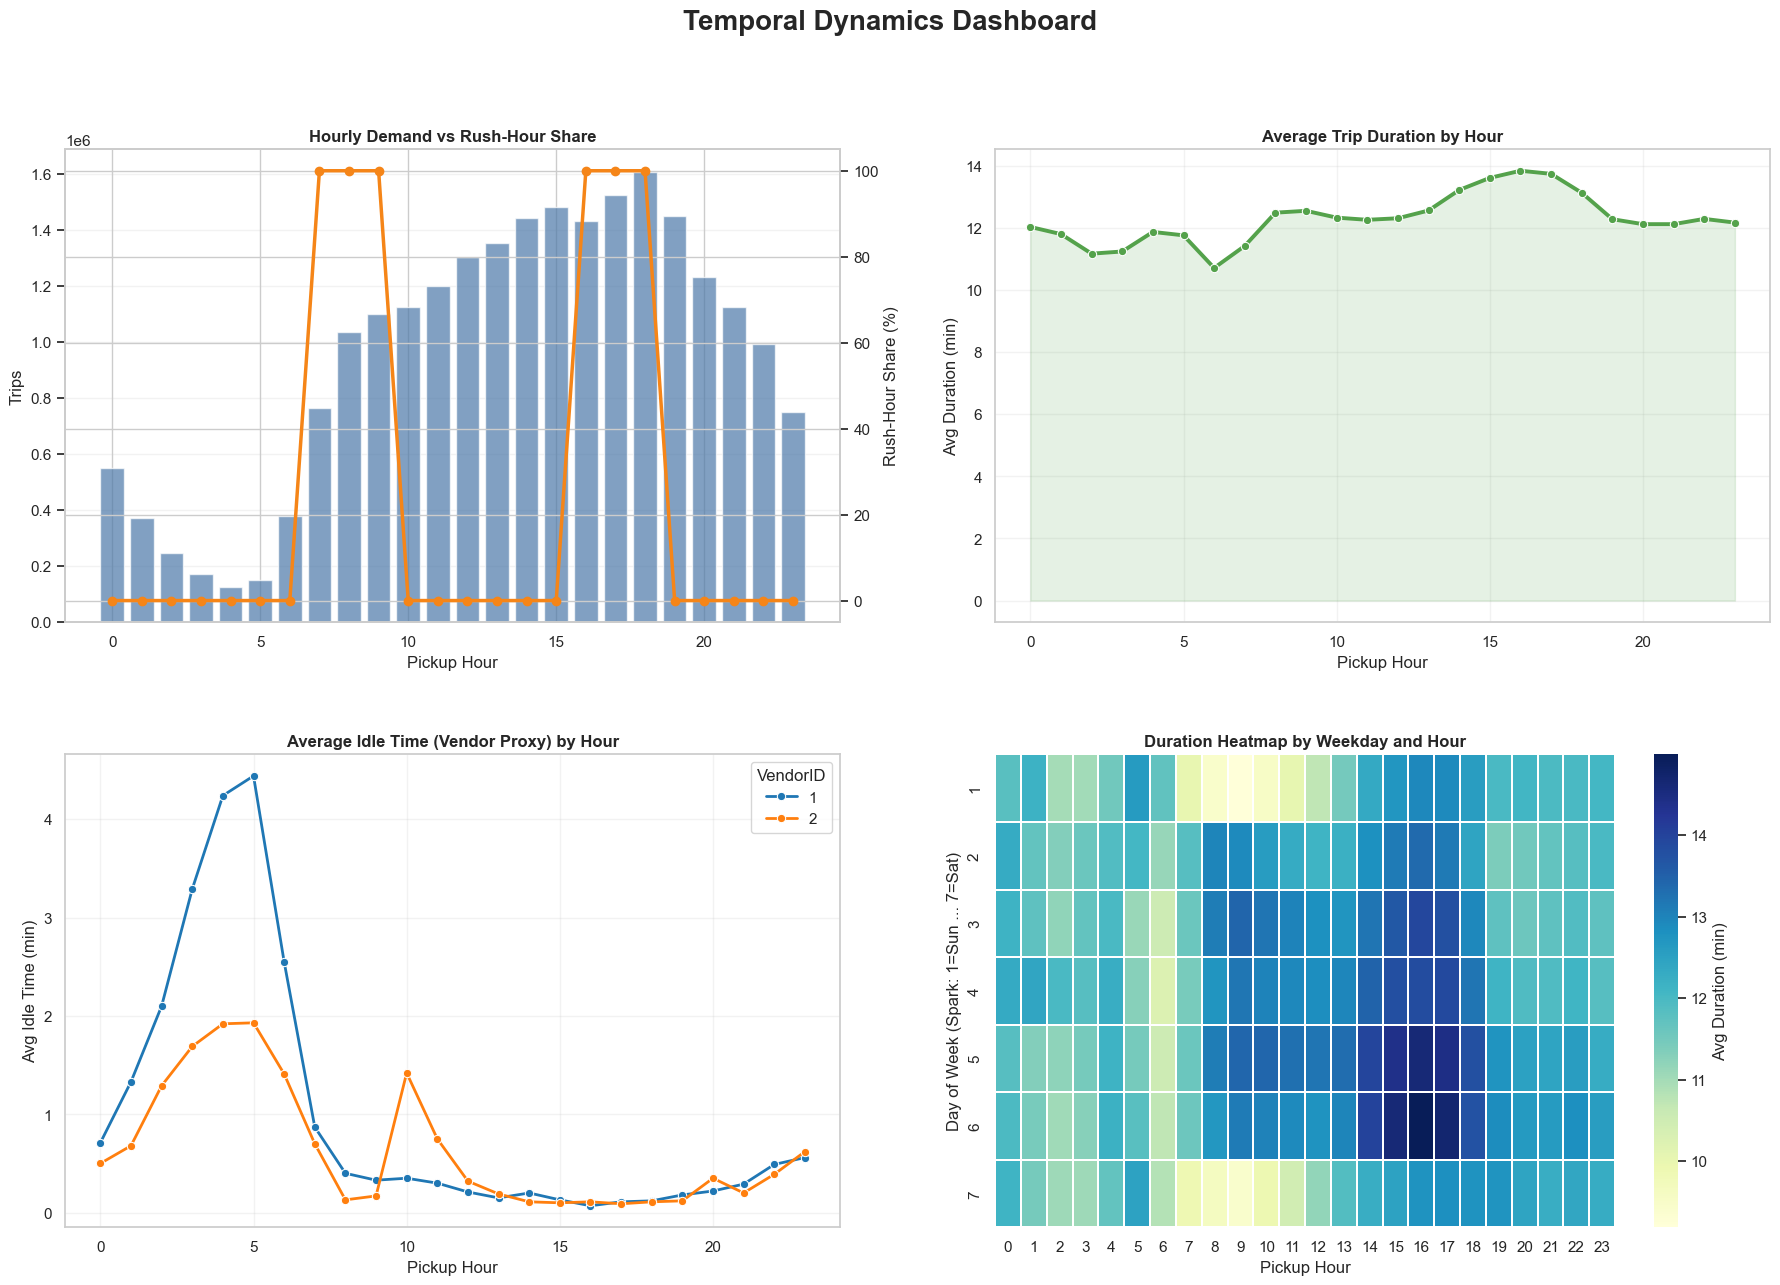

In [24]:
# Advanced visual dashboard for temporal dynamics

rush_by_hour = spark.sql("""
SELECT
    pickup_hour,
    COUNT(*) AS trips,
    SUM(CASE WHEN rush_hour_flag = 1 THEN 1 ELSE 0 END) AS rush_trips,
    ROUND(100.0 * SUM(CASE WHEN rush_hour_flag = 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS rush_pct,
    ROUND(AVG(duration_min), 2) AS avg_duration_min
FROM taxi_temporal
GROUP BY pickup_hour
ORDER BY pickup_hour
""").toPandas()

idle_hour_vendor = spark.sql("""
SELECT
    VendorID,
    pickup_hour,
    ROUND(AVG(idle_time_min_vendor), 2) AS avg_idle_min,
    COUNT(*) AS n
FROM taxi_temporal
WHERE idle_time_min_vendor IS NOT NULL
  AND idle_time_min_vendor >= 0
  AND idle_time_min_vendor < 720
GROUP BY VendorID, pickup_hour
ORDER BY VendorID, pickup_hour
""").toPandas()

dow_hour_duration = spark.sql("""
SELECT
    pickup_dow,
    pickup_hour,
    ROUND(AVG(duration_min), 2) AS avg_duration_min
FROM taxi_temporal
GROUP BY pickup_dow, pickup_hour
ORDER BY pickup_dow, pickup_hour
""").toPandas()

fig = plt.figure(figsize=(22, 14))
gs = fig.add_gridspec(2, 2, hspace=0.28, wspace=0.2)

# 1) Rush-hour rate and volume by hour
ax1 = fig.add_subplot(gs[0, 0])
ax1_t = ax1.twinx()
ax1.bar(rush_by_hour['pickup_hour'], rush_by_hour['trips'], color='#4c78a8', alpha=0.7, label='Trips')
ax1_t.plot(rush_by_hour['pickup_hour'], rush_by_hour['rush_pct'], color='#f58518', marker='o', linewidth=2.5, label='Rush %')
ax1.set_title('Hourly Demand vs Rush-Hour Share', fontweight='bold')
ax1.set_xlabel('Pickup Hour')
ax1.set_ylabel('Trips')
ax1_t.set_ylabel('Rush-Hour Share (%)')
ax1.grid(axis='y', alpha=0.25)

# 2) Duration profile by hour
ax2 = fig.add_subplot(gs[0, 1])
sns.lineplot(data=rush_by_hour, x='pickup_hour', y='avg_duration_min', marker='o', linewidth=2.8, color='#54a24b', ax=ax2)
ax2.fill_between(rush_by_hour['pickup_hour'], 0, rush_by_hour['avg_duration_min'], alpha=0.15, color='#54a24b')
ax2.set_title('Average Trip Duration by Hour', fontweight='bold')
ax2.set_xlabel('Pickup Hour')
ax2.set_ylabel('Avg Duration (min)')
ax2.grid(alpha=0.25)

# 3) Idle-time profile by vendor and hour
ax3 = fig.add_subplot(gs[1, 0])
if not idle_hour_vendor.empty:
    sns.lineplot(
        data=idle_hour_vendor,
        x='pickup_hour',
        y='avg_idle_min',
        hue='VendorID',
        marker='o',
        linewidth=2,
        palette='tab10',
        ax=ax3
    )
ax3.set_title('Average Idle Time (Vendor Proxy) by Hour', fontweight='bold')
ax3.set_xlabel('Pickup Hour')
ax3.set_ylabel('Avg Idle Time (min)')
ax3.grid(alpha=0.25)

# 4) Heatmap of duration by weekday/hour
ax4 = fig.add_subplot(gs[1, 1])
heat = dow_hour_duration.pivot(index='pickup_dow', columns='pickup_hour', values='avg_duration_min').sort_index()
heat = heat.apply(pd.to_numeric, errors='coerce').fillna(0.0)
sns.heatmap(heat, cmap='YlGnBu', linewidths=0.3, cbar_kws={'label': 'Avg Duration (min)'}, ax=ax4)
ax4.set_title('Duration Heatmap by Weekday and Hour', fontweight='bold')
ax4.set_xlabel('Pickup Hour')
ax4.set_ylabel('Day of Week (Spark: 1=Sun ... 7=Sat)')

fig.suptitle('Temporal Dynamics Dashboard', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

### Insight
The combined view shows that demand peaks and duration slowdowns do not always occur at the same time, while vendor idle-time patterns suggest different utilization profiles across the day. Together, these panels separate traffic pressure from operational inactivity, which is the main value of this dashboard.

## Query 4: Fare Efficiency by Time of Day

This analysis studies the relationship between demand timing, trip distance, duration, and fare efficiency. We aggregate trips by time bucket and compare average fare-per-mile with average duration to identify periods with heavier traffic pressure and lower operational efficiency.

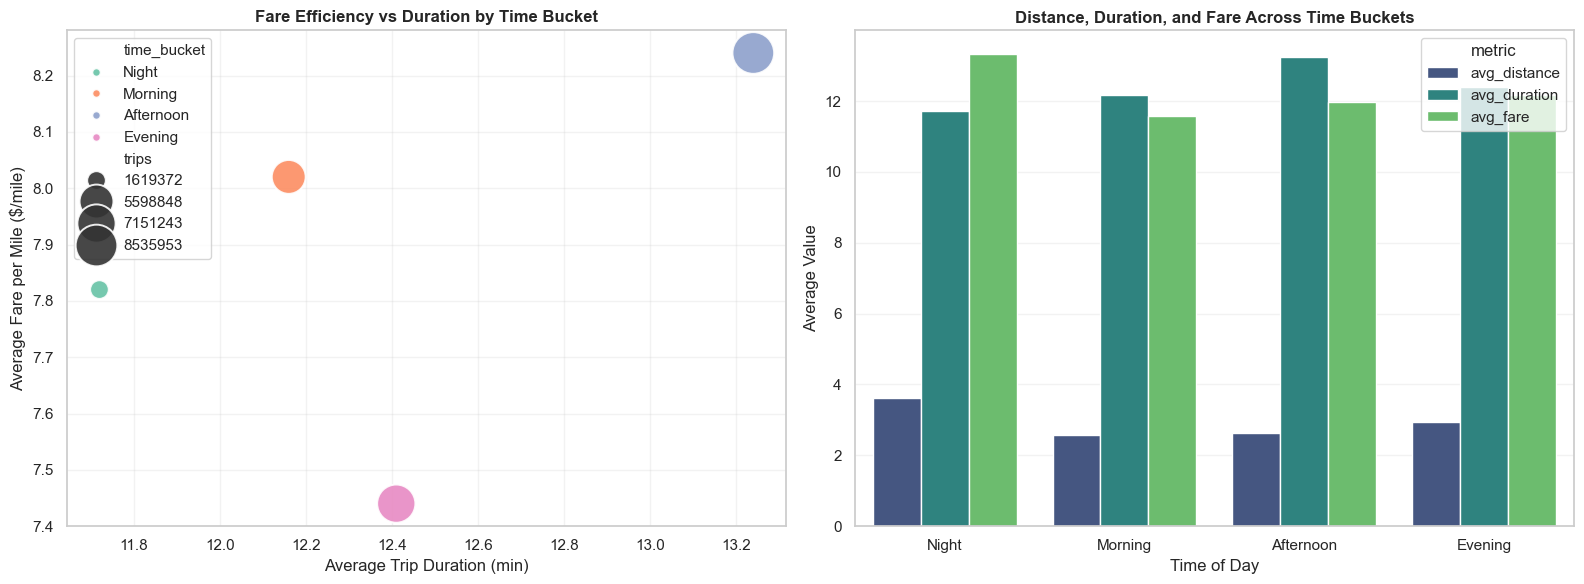

In [33]:
q4_time_efficiency = spark.sql("""
SELECT
    CASE
        WHEN pickup_hour BETWEEN 0 AND 5 THEN 'Night'
        WHEN pickup_hour BETWEEN 6 AND 11 THEN 'Morning'
        WHEN pickup_hour BETWEEN 12 AND 17 THEN 'Afternoon'
        ELSE 'Evening'
    END AS time_bucket,
    COUNT(*) AS trips,
    ROUND(AVG(trip_distance), 2) AS avg_distance,
    ROUND(AVG(duration_min), 2) AS avg_duration,
    ROUND(AVG(fare_amount), 2) AS avg_fare,
    ROUND(AVG(fare_amount / NULLIF(trip_distance, 0)), 2) AS avg_fare_per_mile
FROM taxi_temporal
WHERE trip_distance > 0
GROUP BY
    CASE
        WHEN pickup_hour BETWEEN 0 AND 5 THEN 'Night'
        WHEN pickup_hour BETWEEN 6 AND 11 THEN 'Morning'
        WHEN pickup_hour BETWEEN 12 AND 17 THEN 'Afternoon'
        ELSE 'Evening'
    END
ORDER BY trips DESC
""").toPandas()

bucket_order = ['Night', 'Morning', 'Afternoon', 'Evening']
q4_time_efficiency['time_bucket'] = pd.Categorical(q4_time_efficiency['time_bucket'], categories=bucket_order, ordered=True)
q4_time_efficiency = q4_time_efficiency.sort_values('time_bucket')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Relationship plot: fare-per-mile vs duration
sns.scatterplot(
    data=q4_time_efficiency,
    x='avg_duration',
    y='avg_fare_per_mile',
    size='trips',
    hue='time_bucket',
    sizes=(180, 900),
    palette='Set2',
    alpha=0.9,
    ax=axes[0]
)
axes[0].set_title('Fare Efficiency vs Duration by Time Bucket', fontweight='bold')
axes[0].set_xlabel('Average Trip Duration (min)')
axes[0].set_ylabel('Average Fare per Mile ($/mile)')
axes[0].grid(alpha=0.25)

# Comparative multi-metric bar chart
q4_melt = q4_time_efficiency.melt(
    id_vars='time_bucket',
    value_vars=['avg_distance', 'avg_duration', 'avg_fare'],
    var_name='metric',
    value_name='value'
)

sns.barplot(
    data=q4_melt,
    x='time_bucket',
    y='value',
    hue='metric',
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('Distance, Duration, and Fare Across Time Buckets', fontweight='bold')
axes[1].set_xlabel('Time of Day')
axes[1].set_ylabel('Average Value')
axes[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

### Insight

Time buckets with longer average durations generally show reduced fare efficiency (higher duration per mile), which is consistent with congestion effects. The combined view helps distinguish whether fare differences are primarily explained by distance, time, or both.

## Query 5: Borough-to-Borough Flow Intensity and Cost-Duration Relationship

This analysis looks at inter-borough movements to identify heavy mobility corridors and compare how average fare and duration co-vary across them. It helps reveal whether expensive corridors are distance-driven or delay-driven.

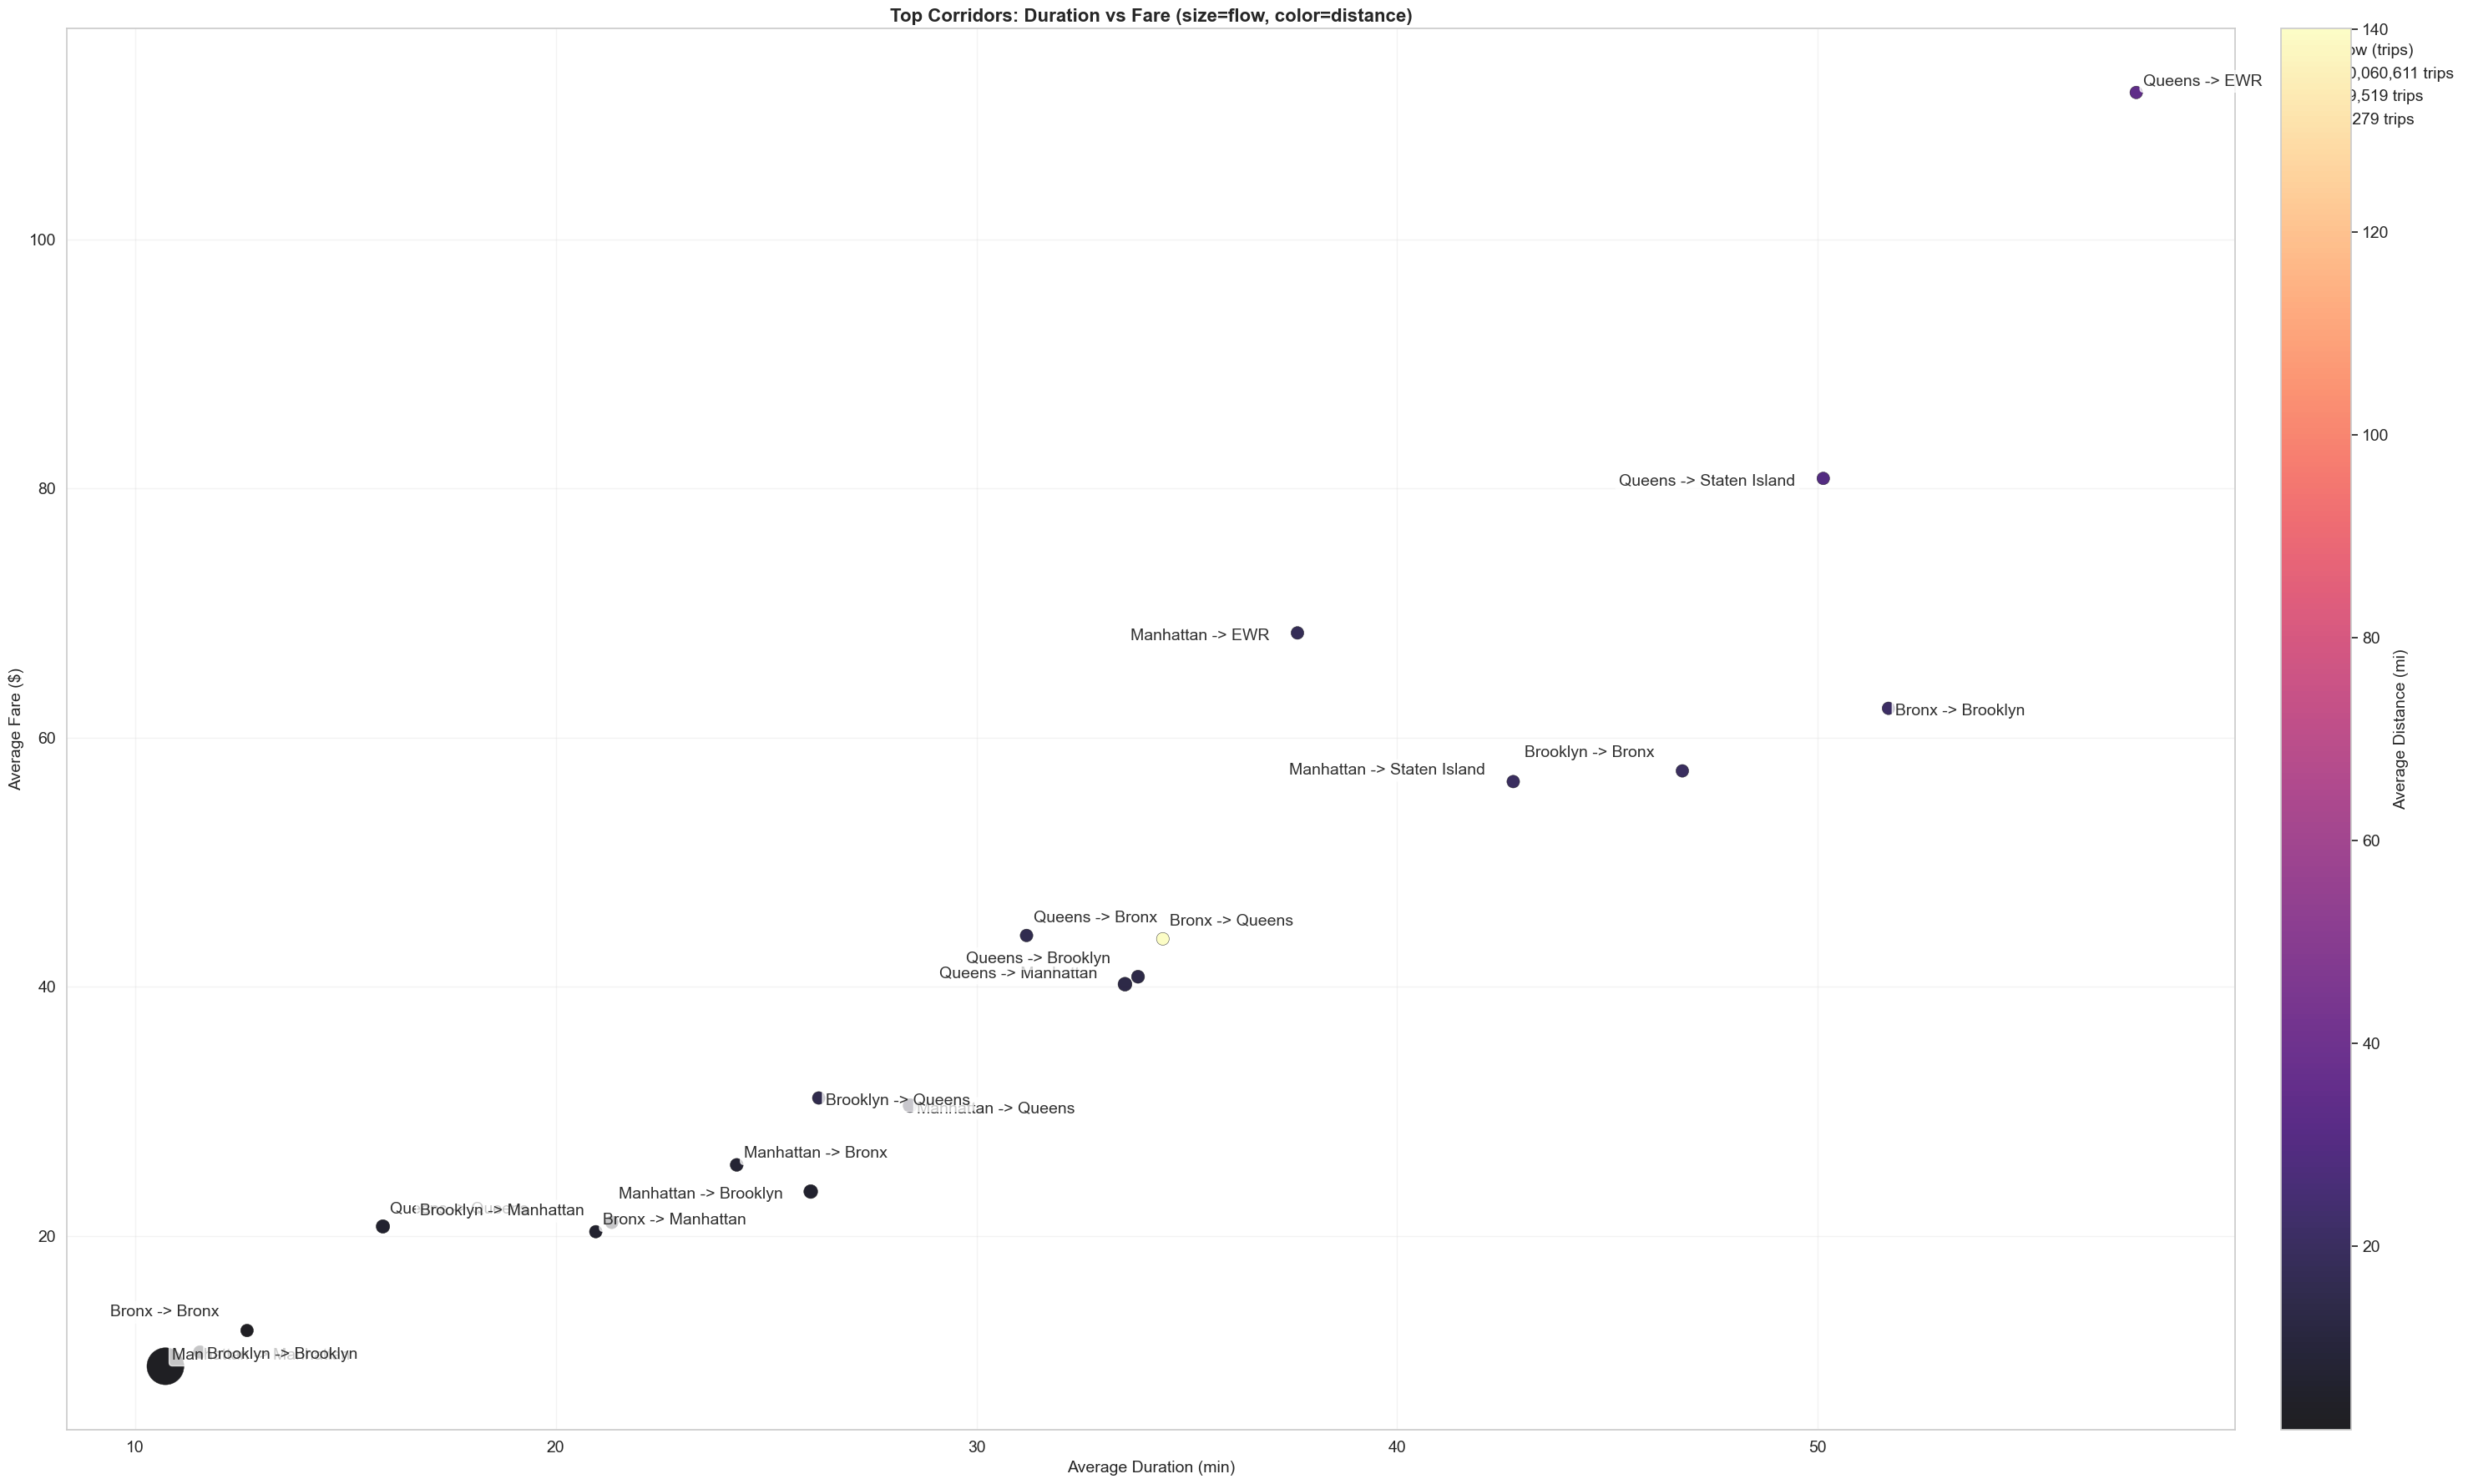

In [50]:
q5_corridor = spark.sql("""
SELECT
    PU_Borough,
    DO_Borough,
    COUNT(*) AS trips,
    ROUND(AVG(duration_min), 2) AS avg_duration,
    ROUND(AVG(trip_distance), 2) AS avg_distance,
    ROUND(AVG(fare_amount), 2) AS avg_fare,
    ROUND(AVG(total_amount), 2) AS avg_total
FROM taxi_temporal
WHERE PU_Borough IS NOT NULL
  AND DO_Borough IS NOT NULL
  AND PU_Borough <> 'Unknown'
  AND DO_Borough <> 'Unknown'
GROUP BY PU_Borough, DO_Borough
HAVING COUNT(*) >= 1000
ORDER BY trips DESC
""").toPandas()

# Build corridor label and keep top flows for relationship plotting
q5_corridor['corridor'] = q5_corridor['PU_Borough'] + ' -> ' + q5_corridor['DO_Borough']
q5_top = q5_corridor.sort_values('trips', ascending=False).head(20).copy()

if not q5_top.empty:
    plt.rcParams.update({
        'font.size': 14,
        'axes.titlesize': 16,
        'axes.labelsize': 14,
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
        'legend.fontsize': 14,
        'legend.title_fontsize': 14,
    })

    fig, ax = plt.subplots(figsize=(30, 18))

    max_trips = q5_top['trips'].max()
    sizes = 120 + (q5_top['trips'] / max_trips) * 900

    sc = ax.scatter(
        q5_top['avg_duration'],
        q5_top['avg_fare'],
        s=sizes,
        c=q5_top['avg_distance'],
        cmap='magma',
        alpha=0.88,
        edgecolors='k',
        linewidths=0.35
    )

    cb = fig.colorbar(sc, ax=ax, pad=0.02, fraction=0.046)
    cb.set_label('Average Distance (mi)', fontsize=14)
    cb.ax.tick_params(labelsize=14)

    ax.set_title('Top Corridors: Duration vs Fare (size=flow, color=distance)', fontweight='bold', fontsize=16)
    ax.set_xlabel('Average Duration (min)', fontsize=14)
    ax.set_ylabel('Average Fare ($)', fontsize=14)
    ax.tick_params(axis='both', labelsize=14)
    ax.grid(alpha=0.22)

    rep_vals = [int(q5_top['trips'].max()), int(q5_top['trips'].median()), int(q5_top['trips'].min())]
    rep_vals = [v for v in sorted(set(rep_vals), reverse=True) if v > 0]
    legend_handles = [ax.scatter([], [], s=(120 + (val / max_trips) * 900), color='gray', alpha=0.8, edgecolors='k') for val in rep_vals]
    legend_labels = [f"{val:,} trips" for val in rep_vals]
    ax.legend(
        legend_handles,
        legend_labels,
        title='Flow (trips)',
        loc='upper left',
        bbox_to_anchor=(1.02, 1),
        fontsize=14,
        title_fontsize=14,
        frameon=False
    )

    offsets = [(6, 6), (6, -6), (-24, 6), (-24, -6), (6, 12), (-24, 12)]
    for i, (_, r) in enumerate(q5_top.iterrows()):
        x = r['avg_duration']
        y = r['avg_fare']
        dx, dy = offsets[i % len(offsets)]
        ax.annotate(
            r['corridor'],
            (x, y),
            xytext=(dx, dy),
            textcoords='offset points',
            fontsize=14,
            alpha=0.95,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.75),
            ha='left' if dx >= 0 else 'right'
        )

    plt.tight_layout()
    plt.show()
else:
    print('No corridors meet the threshold for visualization.')

### Insight

The corridor scatter separates high-fare routes caused by long distance from those likely affected by slower traffic. Corridors with high duration but moderate distance suggest potential congestion bottlenecks.

In [25]:
# Learning pipelines (Spark ML) for tip and duration

# Build modeling base from SQL-engineered temporal view
#SELECT
#model_base = spark.sql("""
#    VendorID,
#    PULocationID,
#    DOLocationID,
#    payment_type,
#    passenger_count,
#    trip_distance,
#    fare_amount,
#    total_amount,
#    rush_hour_flag,
#    pickup_hour,
#    pickup_dow,
#    duration_min,
#    tip_amount,
#    COALESCE(idle_time_min_vendor, 0.0) AS idle_time_min_vendor
#FROM taxi_temporal
#WHERE trip_distance > 0
#  AND fare_amount >= 0
#  AND total_amount >= 0
#  AND passenger_count > 0
#""")

# Regressors and evaluation
#def train_and_eval_regression(df_in, target_col, label_name):
#    data = df_in.dropna(subset=[target_col])

    # Keep realistic target ranges
#    if target_col == 'tip_amount':
#        data = data.filter((col('tip_amount') >= 0) & (col('tip_amount') < 200))
#    if target_col == 'duration_min':
#        data = data.filter((col('duration_min') > 0) & (col('duration_min') < 300))

#    cat_cols = ['VendorID', 'PULocationID', 'DOLocationID', 'payment_type', 'pickup_dow']
#    num_cols = ['passenger_count', 'trip_distance', 'fare_amount', 'total_amount', 'rush_hour_flag', 'pickup_hour', 'idle_time_min_vendor']

#    for c in cat_cols:
#        data = data.withColumn(c, col(c).cast('string'))

#    indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid='keep') for c in cat_cols]
#    encoders = [OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_oh") for c in cat_cols]

#    assembler = VectorAssembler(
#        inputCols=num_cols + [f"{c}_oh" for c in cat_cols],
#        outputCol='features',
#        handleInvalid='skip'
#    )

#    reg = RandomForestRegressor(
#        featuresCol='features',
#        labelCol=target_col,
#        predictionCol='prediction',
#        numTrees=120,
#        maxDepth=12,
#        seed=42
#    )

#    pipeline = Pipeline(stages=indexers + encoders + [assembler, reg])

#    train_df, test_df = data.randomSplit([0.8, 0.2], seed=42)
#    model = pipeline.fit(train_df)
#    pred = model.transform(test_df)

#    evaluator_rmse = RegressionEvaluator(labelCol=target_col, predictionCol='prediction', metricName='rmse')
#    evaluator_mae = RegressionEvaluator(labelCol=target_col, predictionCol='prediction', metricName='mae')
#    evaluator_r2 = RegressionEvaluator(labelCol=target_col, predictionCol='prediction', metricName='r2')

#    metrics = {
#        'target': label_name,
#        'rows_train': train_df.count(),
#        'rows_test': test_df.count(),
#        'rmse': evaluator_rmse.evaluate(pred),
#        'mae': evaluator_mae.evaluate(pred),
#        'r2': evaluator_r2.evaluate(pred)
#    }

#    return model, pred, metrics


# Pipeline 1: tip prediction
#tip_model, tip_pred, tip_metrics = train_and_eval_regression(model_base, 'tip_amount', 'tip_amount')

# Pipeline 2: trip duration prediction
#dur_model, dur_pred, dur_metrics = train_and_eval_regression(model_base, 'duration_min', 'duration_min')

#metrics_df = pd.DataFrame([tip_metrics, dur_metrics])
#print('Model performance (Spark ML RandomForest):')
#display(metrics_df)

# Pred vs actual diagnostics (sample)
#tip_sample = tip_pred.select('tip_amount', 'prediction').sample(0.08, seed=42).toPandas()
#dur_sample = dur_pred.select('duration_min', 'prediction').sample(0.08, seed=42).toPandas()

#fig, ax = plt.subplots(1, 2, figsize=(16, 6))

#sns.scatterplot(data=tip_sample, x='tip_amount', y='prediction', alpha=0.25, s=22, color='#1f77b4', ax=ax[0])
#lims_tip = [0, min(200, max(tip_sample['tip_amount'].max(), tip_sample['prediction'].max()))]
#ax[0].plot(lims_tip, lims_tip, '--', color='black', linewidth=1.5)
#ax[0].set_title('Tip Model: Actual vs Predicted', fontweight='bold')
#ax[0].set_xlabel('Actual Tip ($)')
#ax[0].set_ylabel('Predicted Tip ($)')
#ax[0].grid(alpha=0.25)

#sns.scatterplot(data=dur_sample, x='duration_min', y='prediction', alpha=0.25, s=22, color='#d62728', ax=ax[1])
#lims_dur = [0, min(300, max(dur_sample['duration_min'].max(), dur_sample['prediction'].max()))]
#ax[1].plot(lims_dur, lims_dur, '--', color='black', linewidth=1.5)
#ax[1].set_title('Duration Model: Actual vs Predicted', fontweight='bold')
#ax[1].set_xlabel('Actual Duration (min)')
#ax[1].set_ylabel('Predicted Duration (min)')
#ax[1].grid(alpha=0.25)

#plt.tight_layout()
#plt.show()